# 🌍 Global CO2 Emissions Analysis (1750–2021)
## A Data-Driven Exploration of Climate Change Through Carbon Data

---

### 📋 Project Overview

This project analyzes **global CO2 emissions** spanning over 270 years (1750–2021), 
using country-level data paired with population figures to uncover trends, patterns, 
and insights about humanity's carbon footprint.

The dataset is sourced from **Our World in Data** and covers fossil fuel emissions, 
land-use change, per-capita figures, and temperature change contributions across 
hundreds of countries and regions.

---

### 🎯 Analysis Questions

We will answer four core questions:

1. 📈 **Trend Over Time** — How have global CO2 emissions changed from 1750 to 2021?
2. 🏭 **Top Emitters** — Which countries emit the most CO2 each year?
3. 👤 **Per-Capita Emissions** — Where does the average person have the highest carbon footprint?
4. 🌱 **Fossil Fuels vs. Land Use** — How have these two major emission sources evolved over time?

---

### 🗂️ Dataset at a Glance

| Property | Detail |
|---|---|
| **Source** | Our World in Data — CO2 and GHG Emissions |
| **Time Range** | 1750 – 2021 |
| **Rows** | 50,598 entries |
| **Columns** | 79 features |
| **Granularity** | Country × Year |

---

*Analyst: Dr. Bahaa | Tool: Python 3 / Jupyter Notebook | Date: June 2026*

In [1]:
# ============================================================
# Cell 2 — Imports & Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

# ── Display Settings ────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ── Plot Style ───────────────────────────────────────────────
plt.rcParams['figure.figsize']  = (14, 6)
plt.rcParams['figure.dpi']      = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']     = 'DejaVu Sans'

# ── Color Palette ────────────────────────────────────────────
COLORS = {
    'primary'   : '#2E86AB',
    'secondary' : '#E84855',
    'accent'    : '#F9A03F',
    'green'     : '#3BB273',
    'dark'      : '#1C1C1E',
    'light'     : '#F5F5F5'
}

# ── Project Paths ────────────────────────────────────────────
BASE_PATH   = '/home/pharmacy/CO2+Emissions'
DATA_PATH   = f'{BASE_PATH}/Raw_Datasets/visualizing_global_co2_data.csv'
VIZ_PATH    = f'{BASE_PATH}/Visualizations'

os.makedirs(VIZ_PATH, exist_ok=True)

print("✅ Libraries imported successfully")
print(f"✅ Visualizations folder ready at: {VIZ_PATH}")

✅ Libraries imported successfully
✅ Visualizations folder ready at: /home/pharmacy/CO2+Emissions/Visualizations


In [2]:
# ============================================================
# Cell 3 — Load Dataset & First Look
# ============================================================

# ── Load Data ────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

# ── Shape ────────────────────────────────────────────────────
print("=" * 50)
print("📦 DATASET SHAPE")
print("=" * 50)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]:,}")

# ── First 5 Rows ─────────────────────────────────────────────
print("\n" + "=" * 50)
print("👀 FIRST 5 ROWS")
print("=" * 50)
display(df.head())

# ── Column Names ─────────────────────────────────────────────
print("\n" + "=" * 50)
print("🗂️  ALL COLUMN NAMES")
print("=" * 50)
for i, col in enumerate(df.columns):
    print(f"  {i:02d}. {col}")

# ── Year Range ───────────────────────────────────────────────
print("\n" + "=" * 50)
print("📅 TIME RANGE")
print("=" * 50)
print(f"  From : {df['year'].min()}")
print(f"  To   : {df['year'].max()}")

# ── Unique Countries ─────────────────────────────────────────
print("\n" + "=" * 50)
print("🌍 UNIQUE COUNTRIES / REGIONS")
print("=" * 50)
print(f"  Total : {df['country'].nunique()}")

📦 DATASET SHAPE
  Rows    : 50,598
  Columns : 79

👀 FIRST 5 ROWS


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1850,AFG,"3,752,993.00",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1851,AFG,"3,767,956.00",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.17,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN
2,Afghanistan,1852,AFG,"3,783,940.00",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.16,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN
3,Afghanistan,1853,AFG,"3,800,954.00",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.16,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN
4,Afghanistan,1854,AFG,"3,818,038.00",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.16,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN



🗂️  ALL COLUMN NAMES
  00. country
  01. year
  02. iso_code
  03. population
  04. gdp
  05. cement_co2
  06. cement_co2_per_capita
  07. co2
  08. co2_growth_abs
  09. co2_growth_prct
  10. co2_including_luc
  11. co2_including_luc_growth_abs
  12. co2_including_luc_growth_prct
  13. co2_including_luc_per_capita
  14. co2_including_luc_per_gdp
  15. co2_including_luc_per_unit_energy
  16. co2_per_capita
  17. co2_per_gdp
  18. co2_per_unit_energy
  19. coal_co2
  20. coal_co2_per_capita
  21. consumption_co2
  22. consumption_co2_per_capita
  23. consumption_co2_per_gdp
  24. cumulative_cement_co2
  25. cumulative_co2
  26. cumulative_co2_including_luc
  27. cumulative_coal_co2
  28. cumulative_flaring_co2
  29. cumulative_gas_co2
  30. cumulative_luc_co2
  31. cumulative_oil_co2
  32. cumulative_other_co2
  33. energy_per_capita
  34. energy_per_gdp
  35. flaring_co2
  36. flaring_co2_per_capita
  37. gas_co2
  38. gas_co2_per_capita
  39. ghg_excluding_lucf_per_capita
  40. ghg_pe

## 🧹 Phase 2 — Data Cleaning & Preparation

Before we dive into analysis, we need to understand the **quality of our data**.

With 79 columns spanning 270+ years across 278 countries, missing values are 
**expected and normal** — emissions data simply didn't exist for early centuries 
or smaller nations.

### Our cleaning strategy:

| Issue | Strategy |
|---|---|
| **Missing values** | Analyze extent per column — drop or ignore per context |
| **Aggregate rows** | Identify & separate continent/world-level rows from country rows |
| **Key columns** | Select only columns relevant to our 4 analysis questions |
| **Data types** | Verify all numeric columns are correct dtype |

### 🔑 Key Columns We Will Focus On

| Question | Columns Needed |
|---|---|
| Q1 — Global trend | `year`, `country`, `co2` |
| Q2 — Top emitters | `year`, `country`, `co2` |
| Q3 — Per capita | `year`, `country`, `co2_per_capita` |
| Q4 — Fossil vs land use | `year`, `coal_co2`, `oil_co2`, `gas_co2`,

In [3]:
# ============================================================
# Cell 5 — Missing Values Analysis
# ============================================================

# ── Total Missing Per Column ─────────────────────────────────
missing = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]

print("=" * 50)
print("🔍 MISSING VALUES SUMMARY")
print("=" * 50)
print(f"  Columns with NO missing values  : {df.shape[1] - len(missing)}")
print(f"  Columns WITH missing values     : {len(missing)}")
print()
display(missing)

# ── Check Our Key Columns Specifically ───────────────────────
key_cols = [
    'country', 'year', 'co2',
    'co2_per_capita',
    'coal_co2', 'oil_co2', 'gas_co2',
    'land_use_change_co2'
]

print("\n" + "=" * 50)
print("🔑 MISSING VALUES — KEY COLUMNS ONLY")
print("=" * 50)
for col in key_cols:
    missing_n   = df[col].isnull().sum()
    missing_p   = missing_n / len(df) * 100
    status      = "✅" if missing_n == 0 else "⚠️"
    print(f"  {status} {col:<30} {missing_n:>6,} missing  ({missing_p:.1f}%)")

# ── Check Aggregate Rows (World / Continents) ─────────────────
print("\n" + "=" * 50)
print("🌐 AGGREGATE REGIONS DETECTED")
print("=" * 50)
no_iso = df[df['iso_code'].isnull()]['country'].unique()
print(f"  Total non-country rows : {len(no_iso)}")
print()
for region in sorted(no_iso):
    print(f"  → {region}")

🔍 MISSING VALUES SUMMARY
  Columns with NO missing values  : 2
  Columns WITH missing values     : 77



,missing_count,missing_pct
other_co2_per_capita,48212,95.28
share_global_cumulative_other_co2,48212,95.28
cumulative_other_co2,48212,95.28
other_industry_co2,48212,95.28
share_global_other_co2,48212,95.28
...,...,...
population,10590,20.93
share_of_temperature_change_from_ghg,8874,17.54
temperature_change_from_co2,8874,17.54
temperature_change_from_ghg,8874,17.54



🔑 MISSING VALUES — KEY COLUMNS ONLY
  ✅ country                             0 missing  (0.0%)
  ✅ year                                0 missing  (0.0%)
  ⚠️ co2                            19,249 missing  (38.0%)
  ⚠️ co2_per_capita                 23,683 missing  (46.8%)
  ⚠️ coal_co2                       25,529 missing  (50.5%)
  ⚠️ oil_co2                        25,556 missing  (50.5%)
  ⚠️ gas_co2                        25,655 missing  (50.7%)
  ⚠️ land_use_change_co2            11,210 missing  (22.2%)

🌐 AGGREGATE REGIONS DETECTED
  Total non-country rows : 46

  → Africa
  → Africa (GCP)
  → Asia
  → Asia (GCP)
  → Asia (excl. China and India)
  → Central America (GCP)
  → Europe
  → Europe (GCP)
  → Europe (excl. EU-27)
  → Europe (excl. EU-28)
  → European Union (27)
  → European Union (27) (GCP)
  → European Union (28)
  → French Equatorial Africa (GCP)
  → French Equatorial Africa (Jones et al. 2023)
  → French West Africa (GCP)
  → French West Africa (Jones et al. 2023)
  →

In [4]:
# ============================================================
# Cell 6 — Data Preparation & Filtering
# ============================================================

# ── Separate Countries from Aggregate Regions ────────────────
df_countries = df[df['iso_code'].notna()].copy()
df_world     = df[df['country'] == 'World'].copy()
df_regions   = df[df['iso_code'].isna()].copy()

print("=" * 50)
print("✂️  DATA SEPARATION")
print("=" * 50)
print(f"  Total rows          : {len(df):,}")
print(f"  Country-level rows  : {len(df_countries):,}")
print(f"  World-level rows    : {len(df_world):,}")
print(f"  Aggregate regions   : {len(df_regions):,}")

# ── Select Key Columns ───────────────────────────────────────
key_cols = [
    'country', 'iso_code', 'year', 'population',
    'co2', 'co2_per_capita',
    'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2',
    'land_use_change_co2', 'cumulative_co2'
]

df_clean    = df_countries[key_cols].copy()
df_world_kc = df_world[key_cols].copy()

print("\n" + "=" * 50)
print("🔑 CLEAN DATAFRAME — KEY COLUMNS")
print("=" * 50)
print(f"  Shape : {df_clean.shape}")
display(df_clean.head())

# ── Year Coverage Check ──────────────────────────────────────
print("\n" + "=" * 50)
print("📅 YEAR COVERAGE — COUNTRIES DATA")
print("=" * 50)
print(f"  From : {df_clean['year'].min()}")
print(f"  To   : {df_clean['year'].max()}")
print(f"  Unique years : {df_clean['year'].nunique()}")

# ── Quick Dtype Verification ─────────────────────────────────
print("\n" + "=" * 50)
print("🔢 DATA TYPES — KEY COLUMNS")
print("=" * 50)
display(df_clean.dtypes)

print("\n✅ Data preparation complete — ready for EDA!")

✂️  DATA SEPARATION
  Total rows          : 50,598
  Country-level rows  : 42,142
  World-level rows    : 272
  Aggregate regions   : 8,456

🔑 CLEAN DATAFRAME — KEY COLUMNS
  Shape : (42142, 12)


,country,iso_code,year,population,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,cement_co2,land_use_change_co2,cumulative_co2
0,Afghanistan,AFG,1850,"3,752,993.00",NaN,NaN,NaN,NaN,NaN,NaN,2.93,NaN
1,Afghanistan,AFG,1851,"3,767,956.00",NaN,NaN,NaN,NaN,NaN,NaN,2.97,NaN
2,Afghanistan,AFG,1852,"3,783,940.00",NaN,NaN,NaN,NaN,NaN,NaN,2.97,NaN
3,Afghanistan,AFG,1853,"3,800,954.00",NaN,NaN,NaN,NaN,NaN,NaN,3.00,NaN
4,Afghanistan,AFG,1854,"3,818,038.00",NaN,NaN,NaN,NaN,NaN,NaN,3.00,NaN



📅 YEAR COVERAGE — COUNTRIES DATA
  From : 1750
  To   : 2021
  Unique years : 272

🔢 DATA TYPES — KEY COLUMNS


country                    str
iso_code                   str
year                     int64
population             float64
co2                    float64
co2_per_capita         float64
coal_co2               float64
oil_co2                float64
gas_co2                float64
cement_co2             float64
land_use_change_co2    float64
cumulative_co2         float64
dtype: object


✅ Data preparation complete — ready for EDA!


## 🔍 Phase 3 — Exploratory Data Analysis (EDA)

Before answering our four core questions, we need to **deeply understand** 
the structure and behavior of our data.

### What we will explore:

| Step | Purpose |
|---|---|
| **Statistical Summary** | Understand ranges, averages, and outliers |
| **Data Coverage by Year** | How many countries report data per year? |
| **Top Countries by Total CO2** | Who are the historically biggest emitters? |
| **Global CO2 Quick Look** | What does the overall world trend look like? |

### 📌 Important Notes

- CO2 values are measured in **million tonnes (Mt)** of CO2
- Per-capita values are in **tonnes per person per year**
- Early years (pre-1850) have very sparse country-level data
- We will use **`df_clean`** for country analysis
- We will use **`df_world`** for global trend analysis

In [5]:
# ============================================================
# Cell 8 — Statistical Summary & Data Coverage
# ============================================================

# ── Statistical Summary — Key Numeric Columns ────────────────
print("=" * 50)
print("📊 STATISTICAL SUMMARY — KEY COLUMNS")
print("=" * 50)
numeric_cols = ['co2', 'co2_per_capita', 'coal_co2', 
                'oil_co2', 'gas_co2', 'land_use_change_co2']
display(df_clean[numeric_cols].describe().T)

# ── Data Coverage by Year ────────────────────────────────────
print("\n" + "=" * 50)
print("📅 DATA COVERAGE BY ERA")
print("=" * 50)

eras = {
    'Pre-Industrial (1750–1799)' : (1750, 1799),
    'Industrial Revolution (1800–1899)' : (1800, 1899),
    'Early Modern (1900–1949)'   : (1900, 1949),
    'Post-War (1950–1999)'       : (1950, 1999),
    'Modern (2000–2021)'         : (2000, 2021)
}

for era, (y1, y2) in eras.items():
    era_df      = df_clean[df_clean['year'].between(y1, y2)]
    countries   = era_df['country'].nunique()
    co2_valid   = era_df['co2'].notna().sum()
    print(f"\n  📌 {era}")
    print(f"     Countries reporting : {countries:>4}")
    print(f"     Valid CO2 rows      : {co2_valid:>6,}")

# ── Top 10 Countries by Total Cumulative CO2 ─────────────────
print("\n" + "=" * 50)
print("🏆 TOP 10 COUNTRIES — TOTAL CUMULATIVE CO2")
print("=" * 50)
top10 = (df_clean.groupby('country')['co2']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())
top10.columns = ['Country', 'Total CO2 (Mt)']
top10['Total CO2 (Mt)'] = top10['Total CO2 (Mt)'].map('{:,.0f}'.format)
display(top10)

# ── Most Recent Year Available Per Country ───────────────────
print("\n" + "=" * 50)
print("📆 MOST RECENT YEAR WITH CO2 DATA")
print("=" * 50)
latest = (df_clean.dropna(subset=['co2'])
                  .groupby('country')['year']
                  .max()
                  .value_counts()
                  .head(5))
print(latest.to_string())
print("\n✅ EDA Summary complete!")

📊 STATISTICAL SUMMARY — KEY COLUMNS


,count,mean,std,min,25%,50%,75%,max
co2,"24,688.00",68.60,400.84,0.00,0.11,1.88,18.00,"11,472.37"
co2_per_capita,"23,047.00",3.85,16.08,0.00,0.13,0.91,4.17,824.46
coal_co2,"21,357.00",37.65,246.28,0.00,0.00,0.25,6.24,"7,955.98"
oil_co2,"21,363.00",26.32,139.46,0.00,0.09,1.01,7.84,"2,644.24"
gas_co2,"21,363.00",11.89,75.37,0.00,0.00,0.00,0.50,"1,674.00"
land_use_change_co2,"36,464.00",27.77,118.52,-237.54,0.04,2.16,13.48,"2,832.24"



📅 DATA COVERAGE BY ERA

  📌 Pre-Industrial (1750–1799)
     Countries reporting :   20
     Valid CO2 rows      :    923

  📌 Industrial Revolution (1800–1899)
     Countries reporting :  232
     Valid CO2 rows      :  4,138

  📌 Early Modern (1900–1949)
     Countries reporting :  232
     Valid CO2 rows      :  4,732

  📌 Post-War (1950–1999)
     Countries reporting :  232
     Valid CO2 rows      : 10,093

  📌 Modern (2000–2021)
     Countries reporting :  232
     Valid CO2 rows      :  4,802

🏆 TOP 10 COUNTRIES — TOTAL CUMULATIVE CO2


,Country,Total CO2 (Mt)
0,United States,"421,907"
1,China,"249,353"
2,Russia,"117,548"
3,Germany,"93,291"
4,United Kingdom,"78,509"
5,Japan,"66,711"
6,India,"57,105"
7,France,"39,106"
8,Canada,"34,115"
9,Ukraine,"30,785"



📆 MOST RECENT YEAR WITH CO2 DATA
year
2021    218
2007      1
1983      1
1920      1

✅ EDA Summary complete!


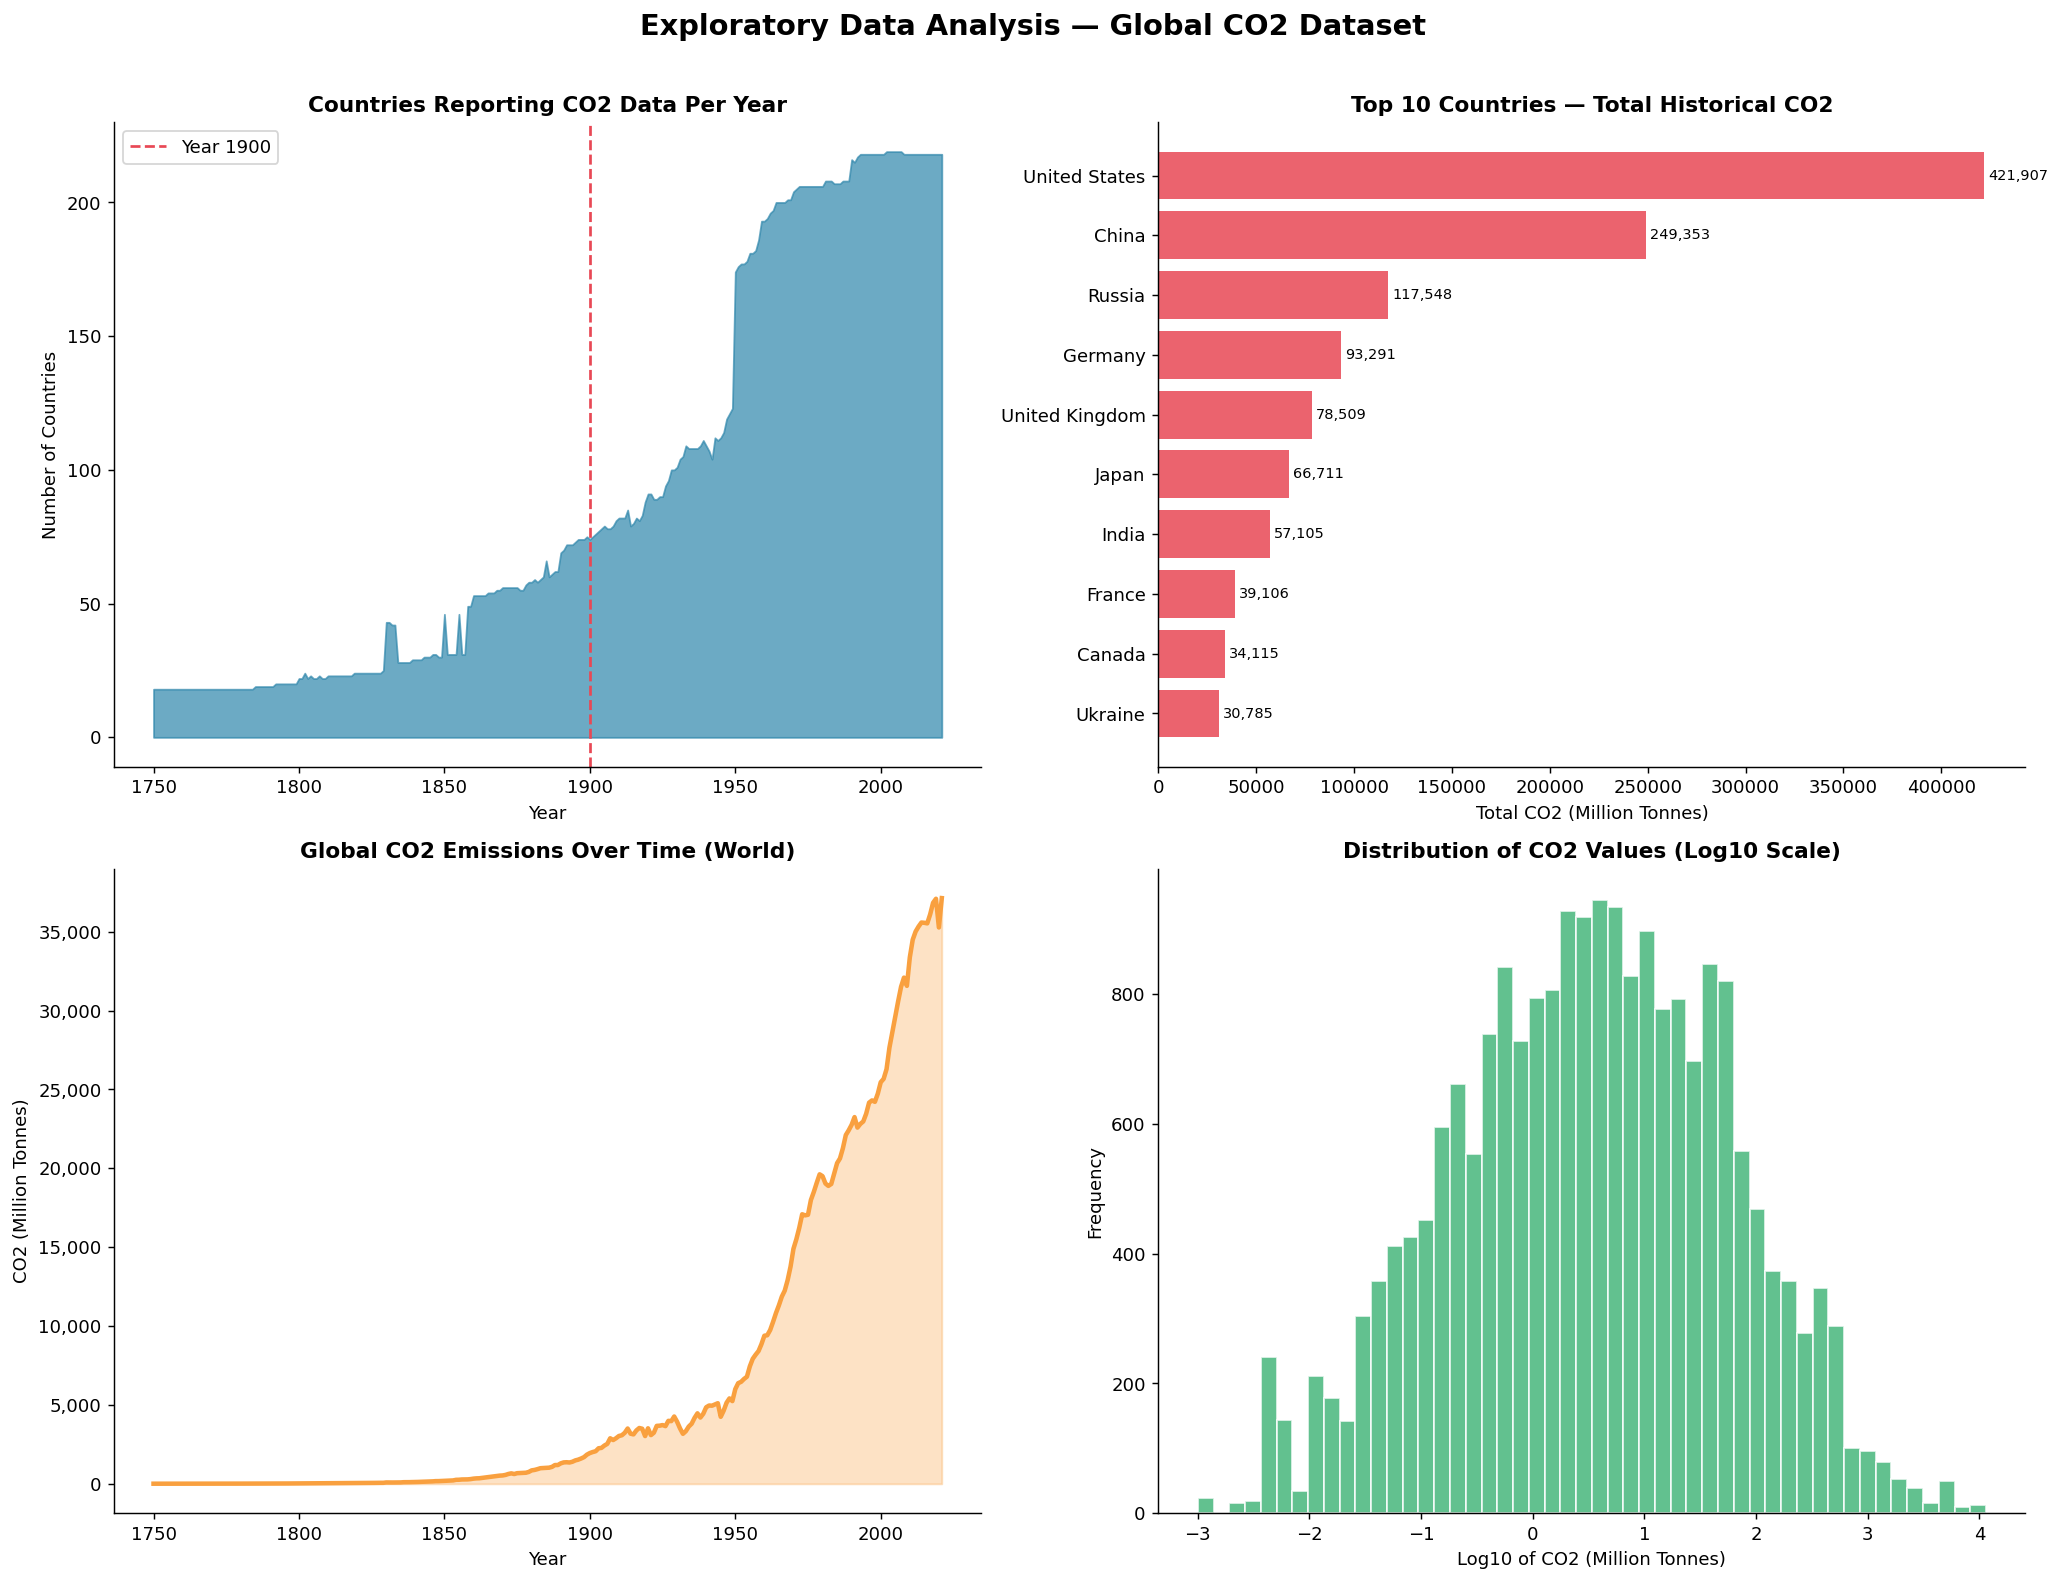

✅ EDA chart saved to Visualizations folder!


In [6]:
# ============================================================
# Cell 9 — EDA Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis — Global CO2 Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Countries Reporting CO2 Data Per Year ────────────
ax1 = axes[0, 0]
coverage = (df_clean.dropna(subset=['co2'])
                    .groupby('year')['country']
                    .nunique())
ax1.fill_between(coverage.index, coverage.values,
                 color=COLORS['primary'], alpha=0.7)
ax1.set_title('Countries Reporting CO2 Data Per Year',
              fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Countries')
ax1.axvline(1900, color=COLORS['secondary'],
            linestyle='--', linewidth=1.5, label='Year 1900')
ax1.legend()

# ── Plot 2: Top 10 Countries Total CO2 ───────────────────────
ax2 = axes[0, 1]
top10_plot = (df_clean.groupby('country')['co2']
                      .sum()
                      .sort_values(ascending=False)
                      .head(10))
bars = ax2.barh(top10_plot.index[::-1],
                top10_plot.values[::-1],
                color=COLORS['secondary'], alpha=0.85)
ax2.set_title('Top 10 Countries — Total Historical CO2',
              fontweight='bold')
ax2.set_xlabel('Total CO2 (Million Tonnes)')
for bar, val in zip(bars, top10_plot.values[::-1]):
    ax2.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=8)

# ── Plot 3: Global CO2 Trend (World) ─────────────────────────
ax3 = axes[1, 0]
world_co2 = df_world.dropna(subset=['co2'])
ax3.plot(world_co2['year'], world_co2['co2'],
         color=COLORS['accent'], linewidth=2.5)
ax3.fill_between(world_co2['year'], world_co2['co2'],
                 alpha=0.3, color=COLORS['accent'])
ax3.set_title('Global CO2 Emissions Over Time (World)',
              fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('CO2 (Million Tonnes)')
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Plot 4: CO2 Distribution (Log Scale) ─────────────────────
ax4 = axes[1, 1]
co2_valid = df_clean['co2'].dropna()
co2_valid = co2_valid[co2_valid > 0]
ax4.hist(np.log10(co2_valid), bins=50,
         color=COLORS['green'], alpha=0.8, edgecolor='white')
ax4.set_title('Distribution of CO2 Values (Log10 Scale)',
              fontweight='bold')
ax4.set_xlabel('Log10 of CO2 (Million Tonnes)')
ax4.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/00_EDA_Overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA chart saved to Visualizations folder!")

## 📈 Question 1 — How Have Global CO2 Emissions Changed Over Time?

### Context

The Industrial Revolution marked a turning point in human history — and in 
our planet's atmosphere. For the first time, fossil fuel combustion began 
releasing carbon that had been stored underground for millions of years.

We will trace this journey from **1750 to 2021** using **world-level data**, 
identifying the key historical turning points that shaped our climate today.

### Key Milestones We Expect to See

| Period | Event | Expected Impact |
|---|---|---|
| **~1760** | Industrial Revolution begins (UK) | First CO2 rise |
| **~1900** | Global industrialization spreads | Accelerating growth |
| **~1945** | Post-WW2 economic boom | Sharp acceleration |
| **~1973** | Oil Crisis | Temporary dip |
| **~2008** | Global Financial Crisis | Noticeable dip |
| **~2020** | COVID-19 Pandemic | Visible drop |

### 📐 Metric Used
> **`co2`** — Annual CO2 emissions in **million tonnes (Mt)**  
> Source: World-level rows from `df_world`

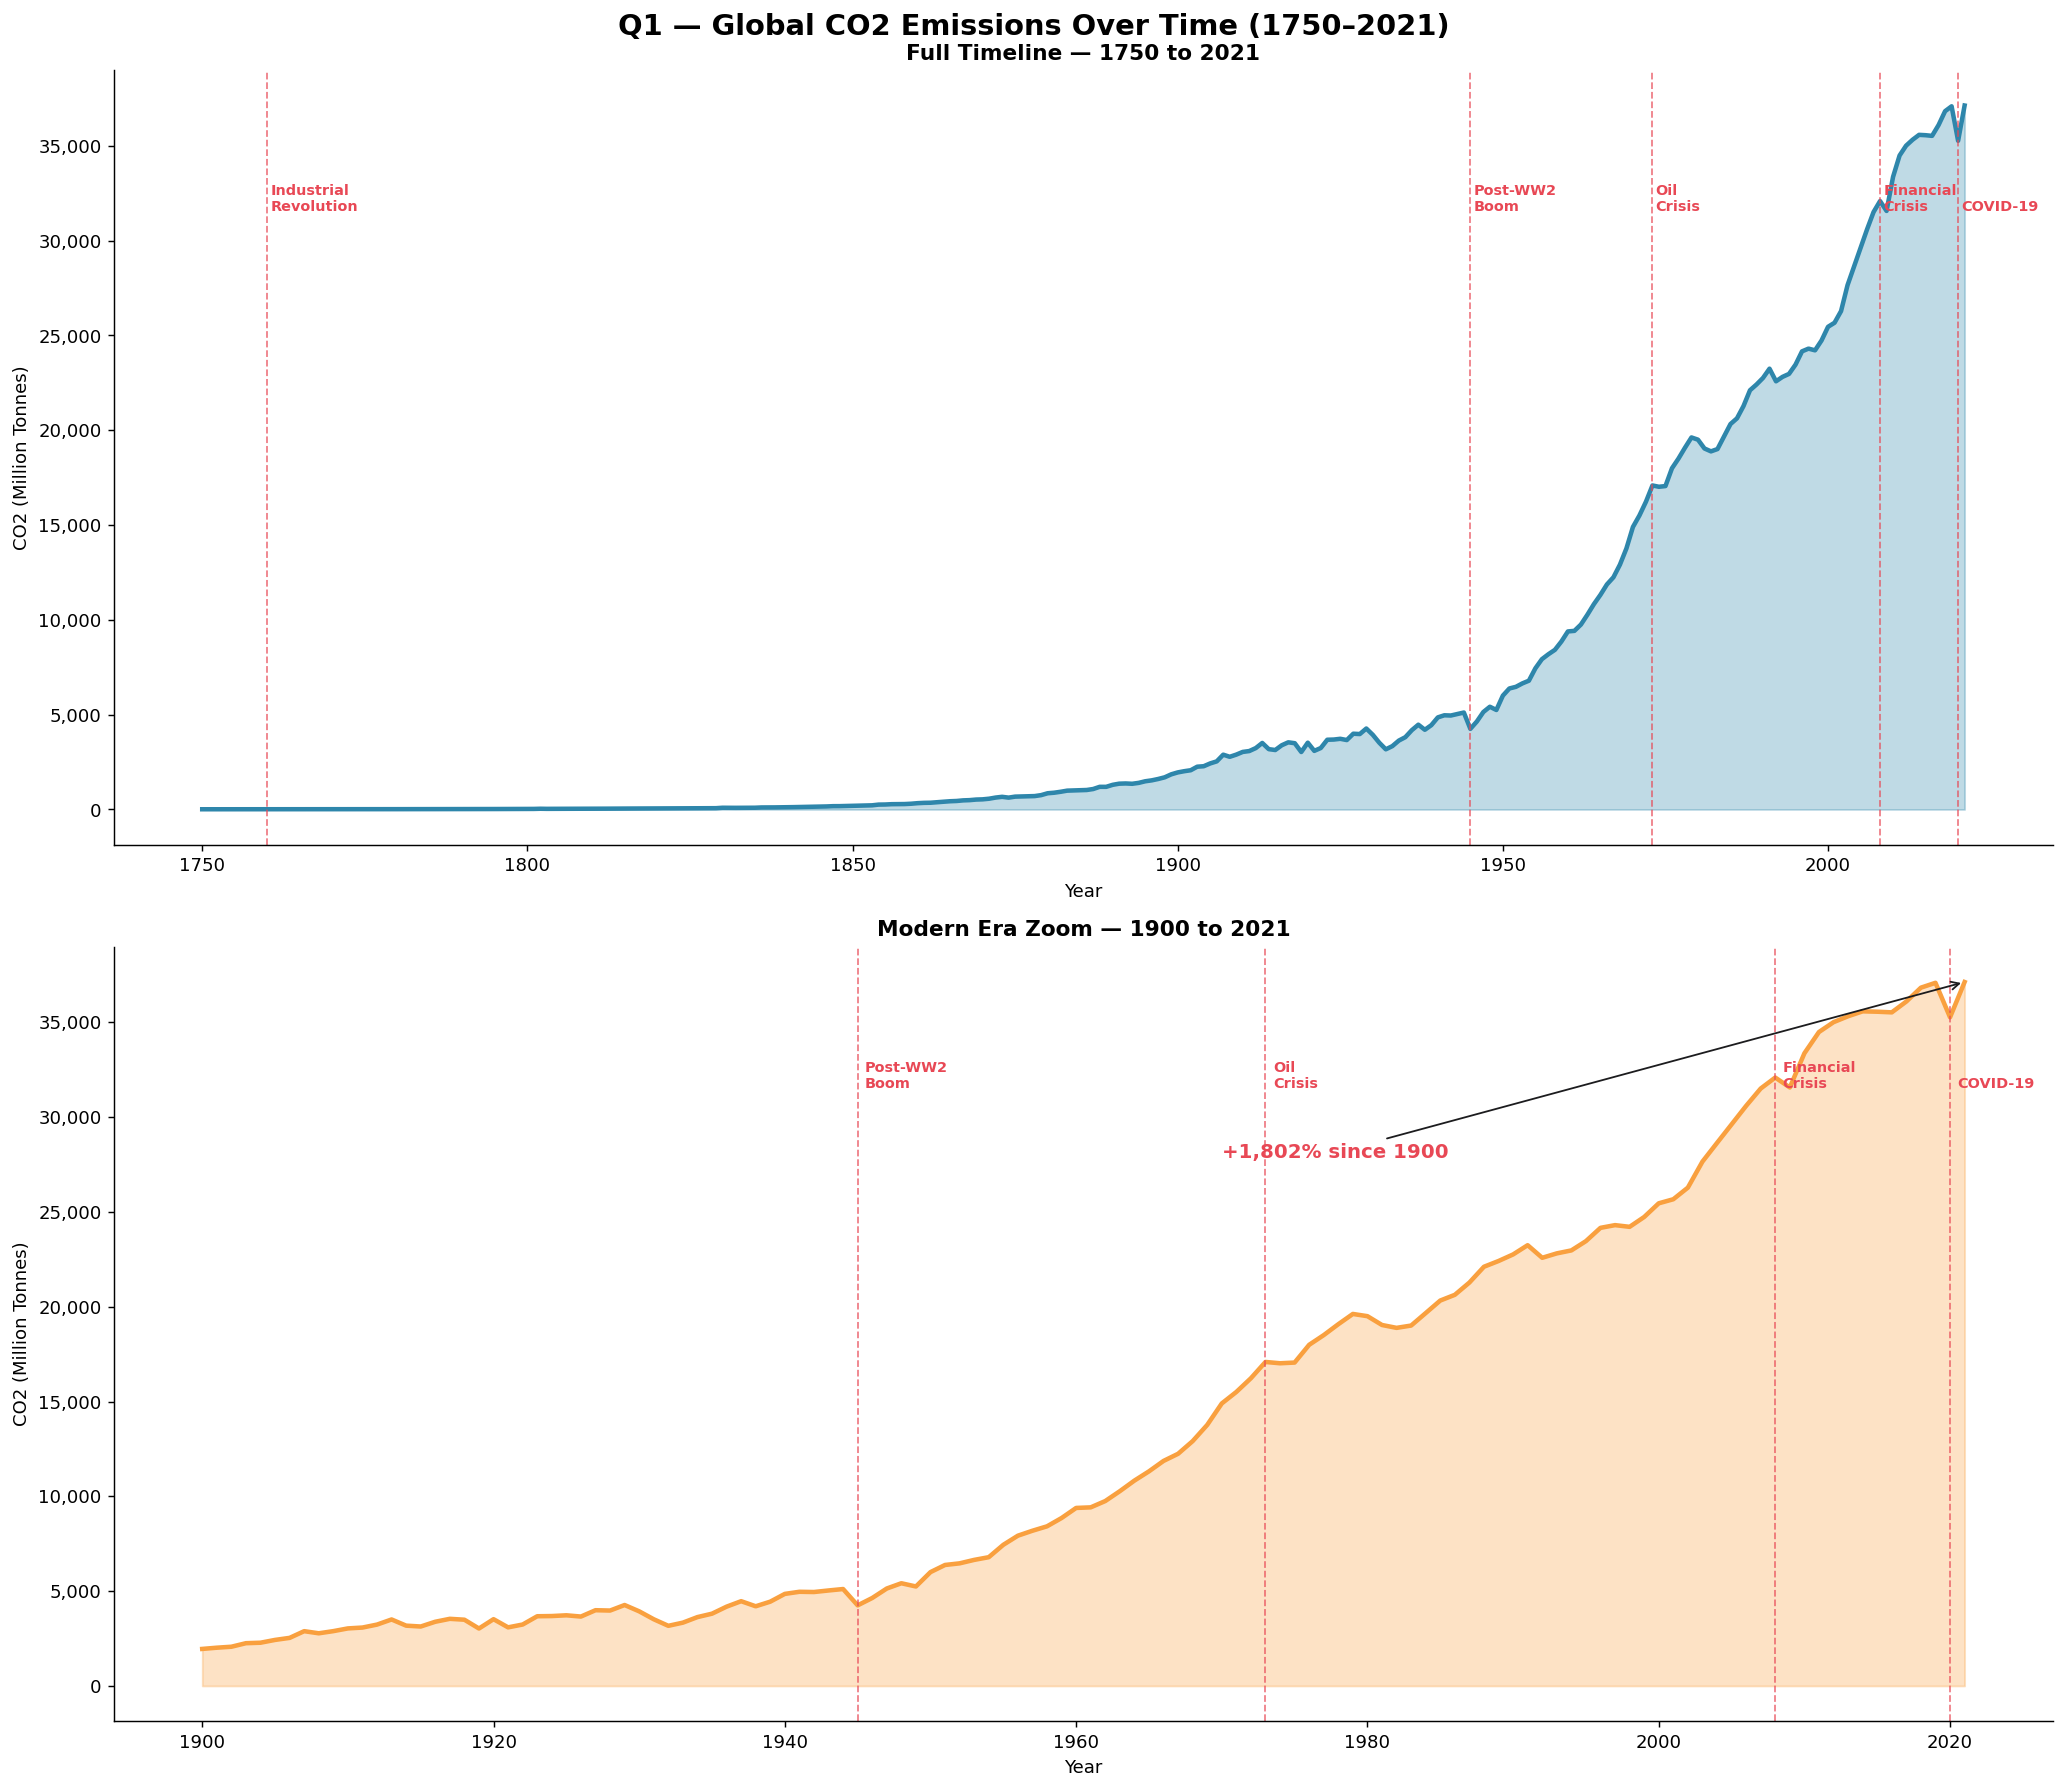

📊 Q1 — KEY NUMBERS
  CO2 in 1750  : 9.35 Mt
  CO2 in 1900  : 1,952.21 Mt
  CO2 in 2021  : 37,123.85 Mt
  Growth 1900→2021 : +1,802%

✅ Q1 chart saved to Visualizations folder!


In [7]:
# ============================================================
# Cell 11 — Q1: Global CO2 Emissions Over Time
# ============================================================

world = df_world.dropna(subset=['co2']).copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 14))
fig.suptitle('Q1 — Global CO2 Emissions Over Time (1750–2021)',
             fontsize=16, fontweight='bold')

# ── Plot 1: Full Timeline ─────────────────────────────────────
ax1 = axes[0]
ax1.fill_between(world['year'], world['co2'],
                 alpha=0.3, color=COLORS['primary'])
ax1.plot(world['year'], world['co2'],
         color=COLORS['primary'], linewidth=2.5)

# Annotate key milestones
milestones = {
    1760 : 'Industrial\nRevolution',
    1945 : 'Post-WW2\nBoom',
    1973 : 'Oil\nCrisis',
    2008 : 'Financial\nCrisis',
    2020 : 'COVID-19'
}

for year, label in milestones.items():
    co2_val = world.loc[world['year'] == year, 'co2']
    if not co2_val.empty:
        ax1.axvline(year, color=COLORS['secondary'],
                    linestyle='--', linewidth=1, alpha=0.7)
        ax1.text(year + 0.5, world['co2'].max() * 0.85,
                 label, fontsize=8, color=COLORS['secondary'],
                 fontweight='bold')

ax1.set_title('Full Timeline — 1750 to 2021', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 (Million Tonnes)')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Plot 2: Modern Era Zoom (1900–2021) ───────────────────────
ax2 = axes[1]
modern = world[world['year'] >= 1900]
ax2.fill_between(modern['year'], modern['co2'],
                 alpha=0.3, color=COLORS['accent'])
ax2.plot(modern['year'], modern['co2'],
         color=COLORS['accent'], linewidth=2.5)

# Annotate percentage growth
co2_1900 = modern.loc[modern['year'] == 1900, 'co2'].values[0]
co2_2021 = modern.loc[modern['year'] == 2021, 'co2'].values[0]
growth   = ((co2_2021 - co2_1900) / co2_1900) * 100

ax2.annotate(f'+{growth:,.0f}% since 1900',
             xy=(2021, co2_2021),
             xytext=(1970, co2_2021 * 0.75),
             arrowprops=dict(arrowstyle='->', color=COLORS['dark']),
             fontsize=11, fontweight='bold',
             color=COLORS['secondary'])

for year, label in milestones.items():
    if year >= 1900:
        ax2.axvline(year, color=COLORS['secondary'],
                    linestyle='--', linewidth=1, alpha=0.7)
        ax2.text(year + 0.5, modern['co2'].max() * 0.85,
                 label, fontsize=8, color=COLORS['secondary'],
                 fontweight='bold')

ax2.set_title('Modern Era Zoom — 1900 to 2021', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('CO2 (Million Tonnes)')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/01_Global_CO2_Trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Key Numbers ───────────────────────────────────────────────
print("=" * 50)
print("📊 Q1 — KEY NUMBERS")
print("=" * 50)
print(f"  CO2 in 1750  : {world.loc[world['year']==1750, 'co2'].values[0]:,.2f} Mt")
print(f"  CO2 in 1900  : {co2_1900:,.2f} Mt")
print(f"  CO2 in 2021  : {co2_2021:,.2f} Mt")
print(f"  Growth 1900→2021 : +{growth:,.0f}%")
print(f"\n✅ Q1 chart saved to Visualizations folder!")

## 🏭 Question 2 — Who Emits the Most CO2 Each Year?

### Context

Global emissions are not distributed equally. A small number of countries 
are responsible for the **majority of the world's CO2 output**.

Understanding *who* emits the most — and *how that has shifted over time* — 
is critical for designing effective climate policy.

### What We Will Analyze

- **Top 10 emitters in the most recent year (2021)**
- **How the top emitters have shifted** across three key eras:
  - 🏭 Industrial Era — 1900
  - ⚙️ Post-War Era — 1970
  - 🌐 Modern Era — 2021
- **Share of global emissions** held by top emitters

### 📐 Metric Used
> **`co2`** — Annual CO2 emissions in **million tonnes (Mt)**  
> Filtered to country-level rows only — using `df_clean`

### 💡 Hypothesis
> We expect the **United States** to dominate early rankings,  
> with **China** overtaking in the modern era,  
> and **India** emerging as a major emitter post-2000.

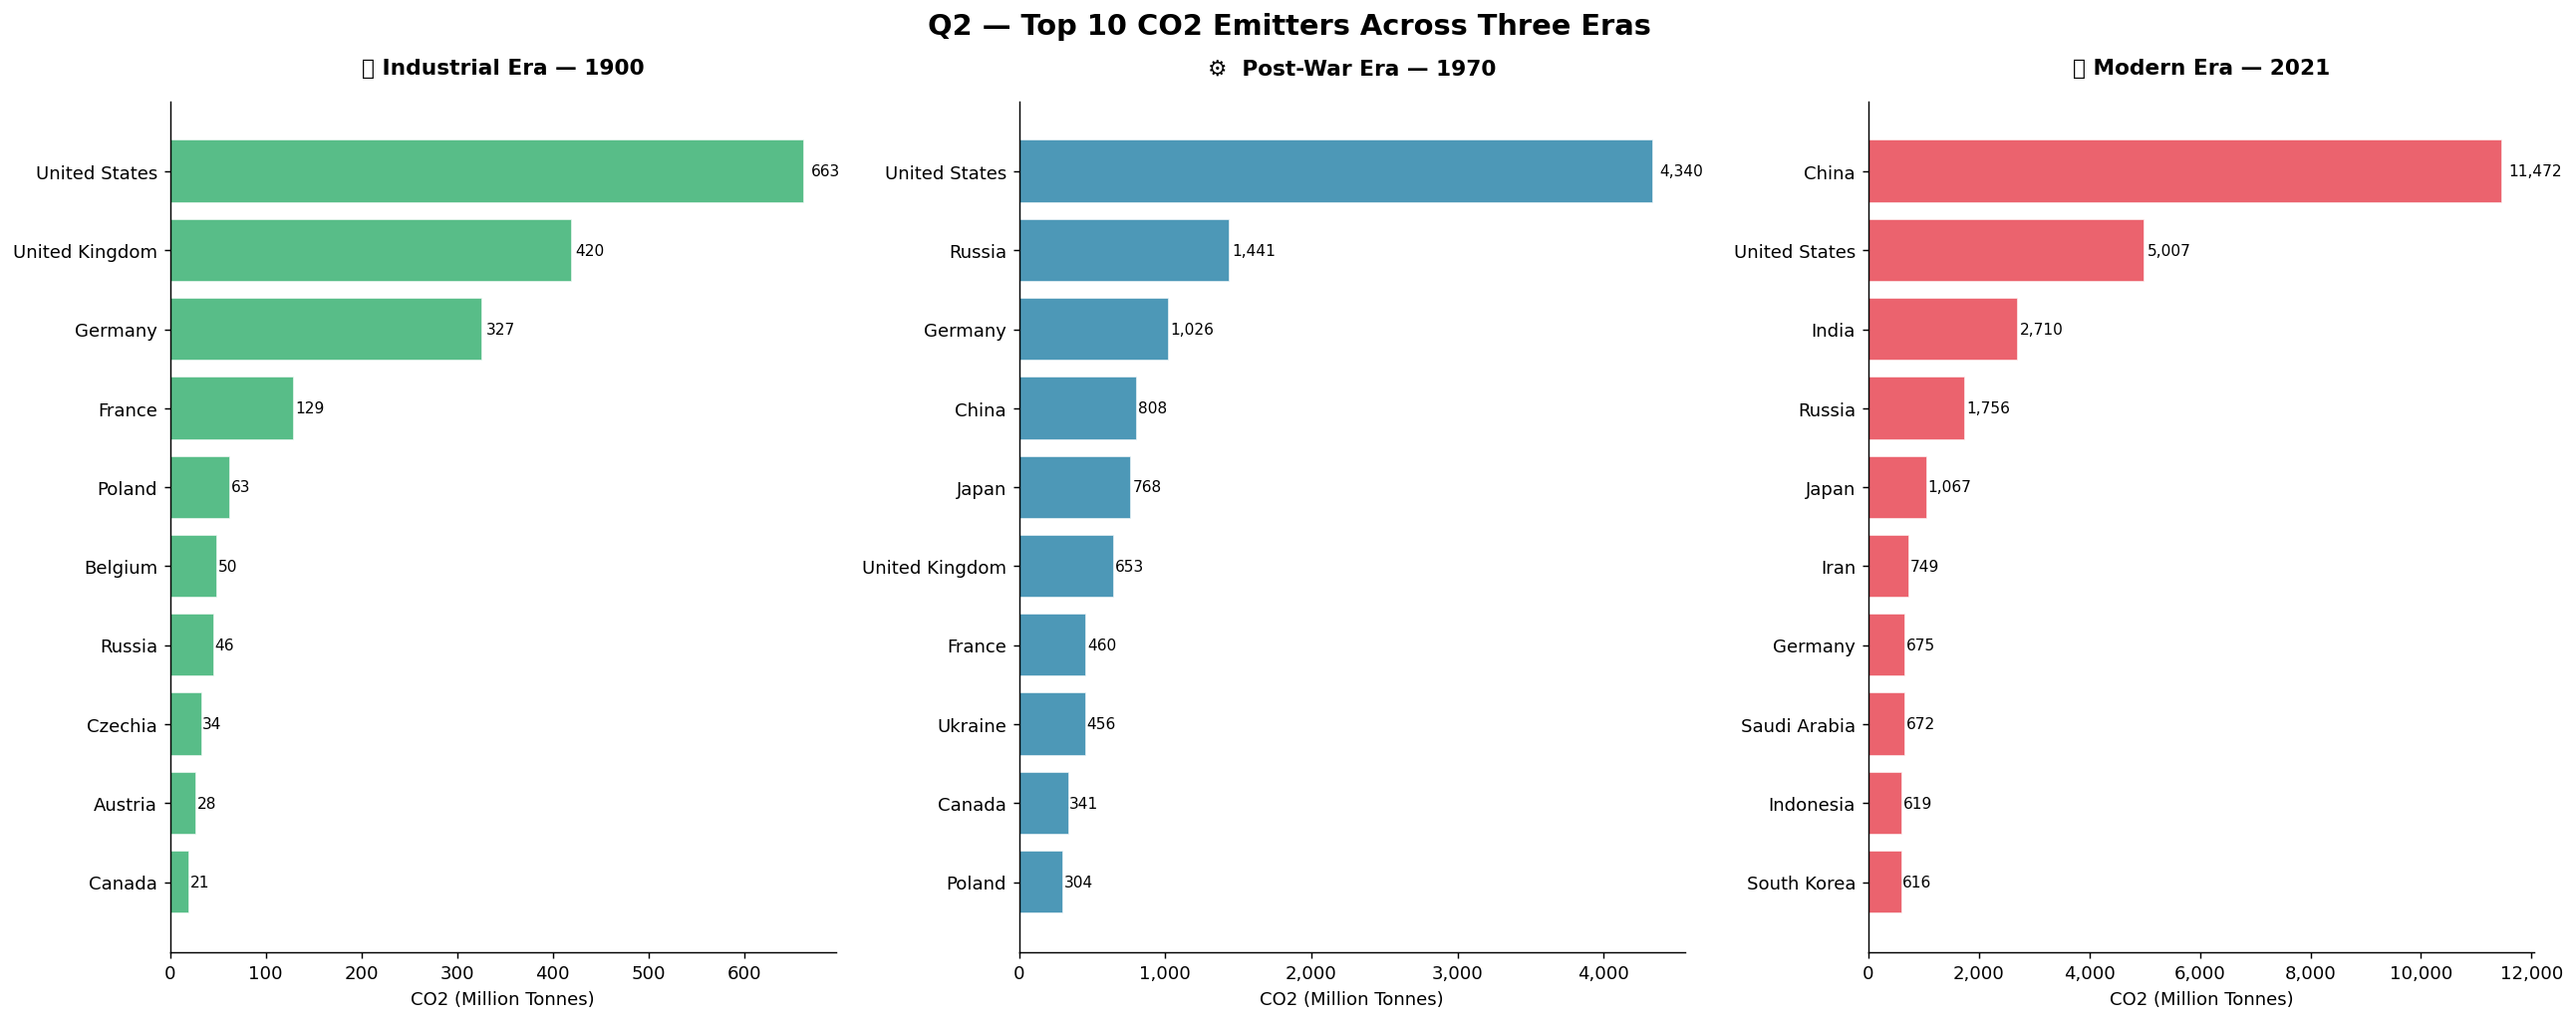

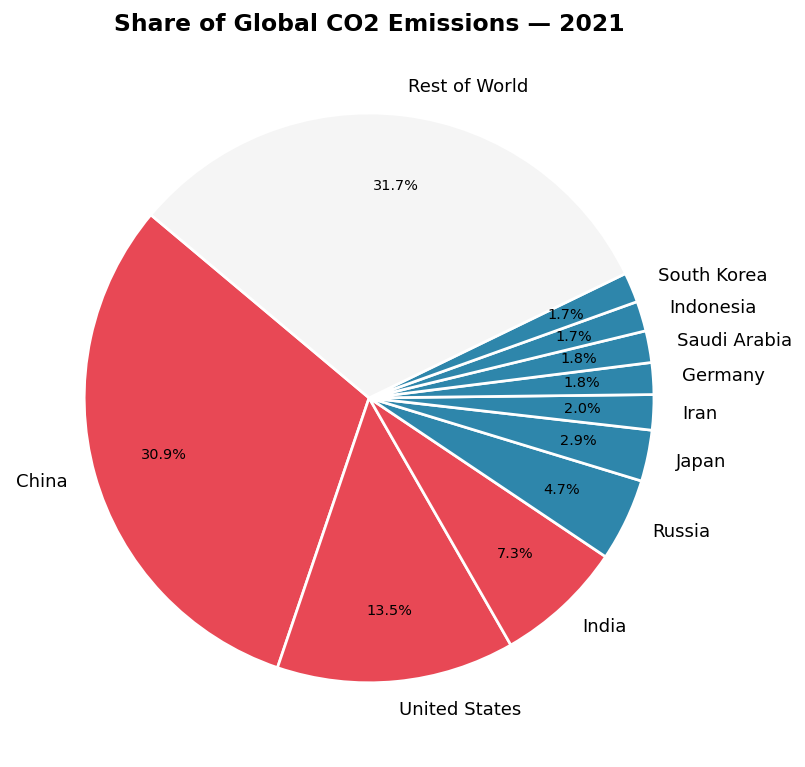

📊 Q2 — KEY NUMBERS

  🌐 World Total CO2 in 2021 : 37,124 Mt

  Top 3 Emitters in 2021:
    → China                  11,472 Mt  (30.9% of global)
    → United States           5,007 Mt  (13.5% of global)
    → India                   2,710 Mt  (7.3% of global)

  Top 10 combined share : 68.3% of global emissions

✅ Q2 charts saved to Visualizations folder!


In [8]:
# ============================================================
# Cell 13 — Q2: Who Emits the Most CO2 Each Year?
# ============================================================

# ── Helper Function ──────────────────────────────────────────
def get_top_emitters(year, n=10):
    return (df_clean[df_clean['year'] == year]
            .dropna(subset=['co2'])
            .nlargest(n, 'co2')[['country', 'co2']]
            .reset_index(drop=True))

# ── Data for Three Eras ──────────────────────────────────────
top_1900 = get_top_emitters(1900)
top_1970 = get_top_emitters(1970)
top_2021 = get_top_emitters(2021)

# ── Figure Setup ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Q2 — Top 10 CO2 Emitters Across Three Eras',
             fontsize=16, fontweight='bold')

datasets = [
    (top_1900, '🏭 Industrial Era — 1900', COLORS['green']),
    (top_1970, '⚙️  Post-War Era — 1970',  COLORS['primary']),
    (top_2021, '🌐 Modern Era — 2021',     COLORS['secondary']),
]

for ax, (data, title, color) in zip(axes, datasets):
    bars = ax.barh(data['country'][::-1],
                   data['co2'][::-1],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=12, pad=15)
    ax.set_xlabel('CO2 (Million Tonnes)')

    # Value labels
    for bar, val in zip(bars, data['co2'][::-1]):
        ax.text(bar.get_width() * 1.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.0f}', va='center', fontsize=8.5)

    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/02_Top_Emitters_Three_Eras.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Share of Global Emissions — 2021 ─────────────────────────
fig2, ax = plt.subplots(figsize=(10, 6))

world_2021 = df_world.loc[df_world['year'] == 2021, 'co2'].values[0]
top_2021['share_pct'] = (top_2021['co2'] / world_2021 * 100).round(1)
others_pct = 100 - top_2021['share_pct'].sum()

pie_data   = list(top_2021['share_pct']) + [others_pct]
pie_labels = list(top_2021['country'])  + ['Rest of World']
pie_colors = [COLORS['secondary']] * 3 + \
             [COLORS['primary']] * 7   + \
             [COLORS['light']]

wedges, texts, autotexts = ax.pie(
    pie_data,
    labels=pie_labels,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts:
    text.set_fontsize(8)

ax.set_title('Share of Global CO2 Emissions — 2021',
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/02_Emissions_Share_2021.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Key Numbers ───────────────────────────────────────────────
print("=" * 50)
print("📊 Q2 — KEY NUMBERS")
print("=" * 50)
print(f"\n  🌐 World Total CO2 in 2021 : {world_2021:,.0f} Mt")
print(f"\n  Top 3 Emitters in 2021:")
for _, row in top_2021.head(3).iterrows():
    print(f"    → {row['country']:<20} "
          f"{row['co2']:>8,.0f} Mt  "
          f"({row['share_pct']:.1f}% of global)")
top10_share = top_2021['share_pct'].sum()
print(f"\n  Top 10 combined share : {top10_share:.1f}% of global emissions")
print(f"\n✅ Q2 charts saved to Visualizations folder!")

## 👤 Question 3 — Where Does the Average Person Emit the Most CO2?

### Context

Total emissions tell only part of the story. A country with a huge population 
might emit a lot in **total** — but its citizens may individually have a 
**small carbon footprint**.

Per-capita analysis reveals the **lifestyle and energy intensity** of each 
nation's economy, making it a fairer measure for international comparison.

### What We Will Analyze

- **Top 20 countries by CO2 per capita in 2021**
- **Regional patterns** — which parts of the world have the 
  highest individual footprints?
- **Trend over time** — how has per-capita CO2 evolved for 
  the world's major emitters?

### 📐 Metric Used
> **`co2_per_capita`** — Annual CO2 emissions per person  
> Unit: **tonnes of CO2 per person per year**  
> Source: country-level rows — `df_clean`

### 💡 Hypothesis
> We expect **oil-rich Gulf states** (Qatar, Kuwait, UAE)  
> to top the per-capita rankings — not China or India,  
> despite their massive total emissions.

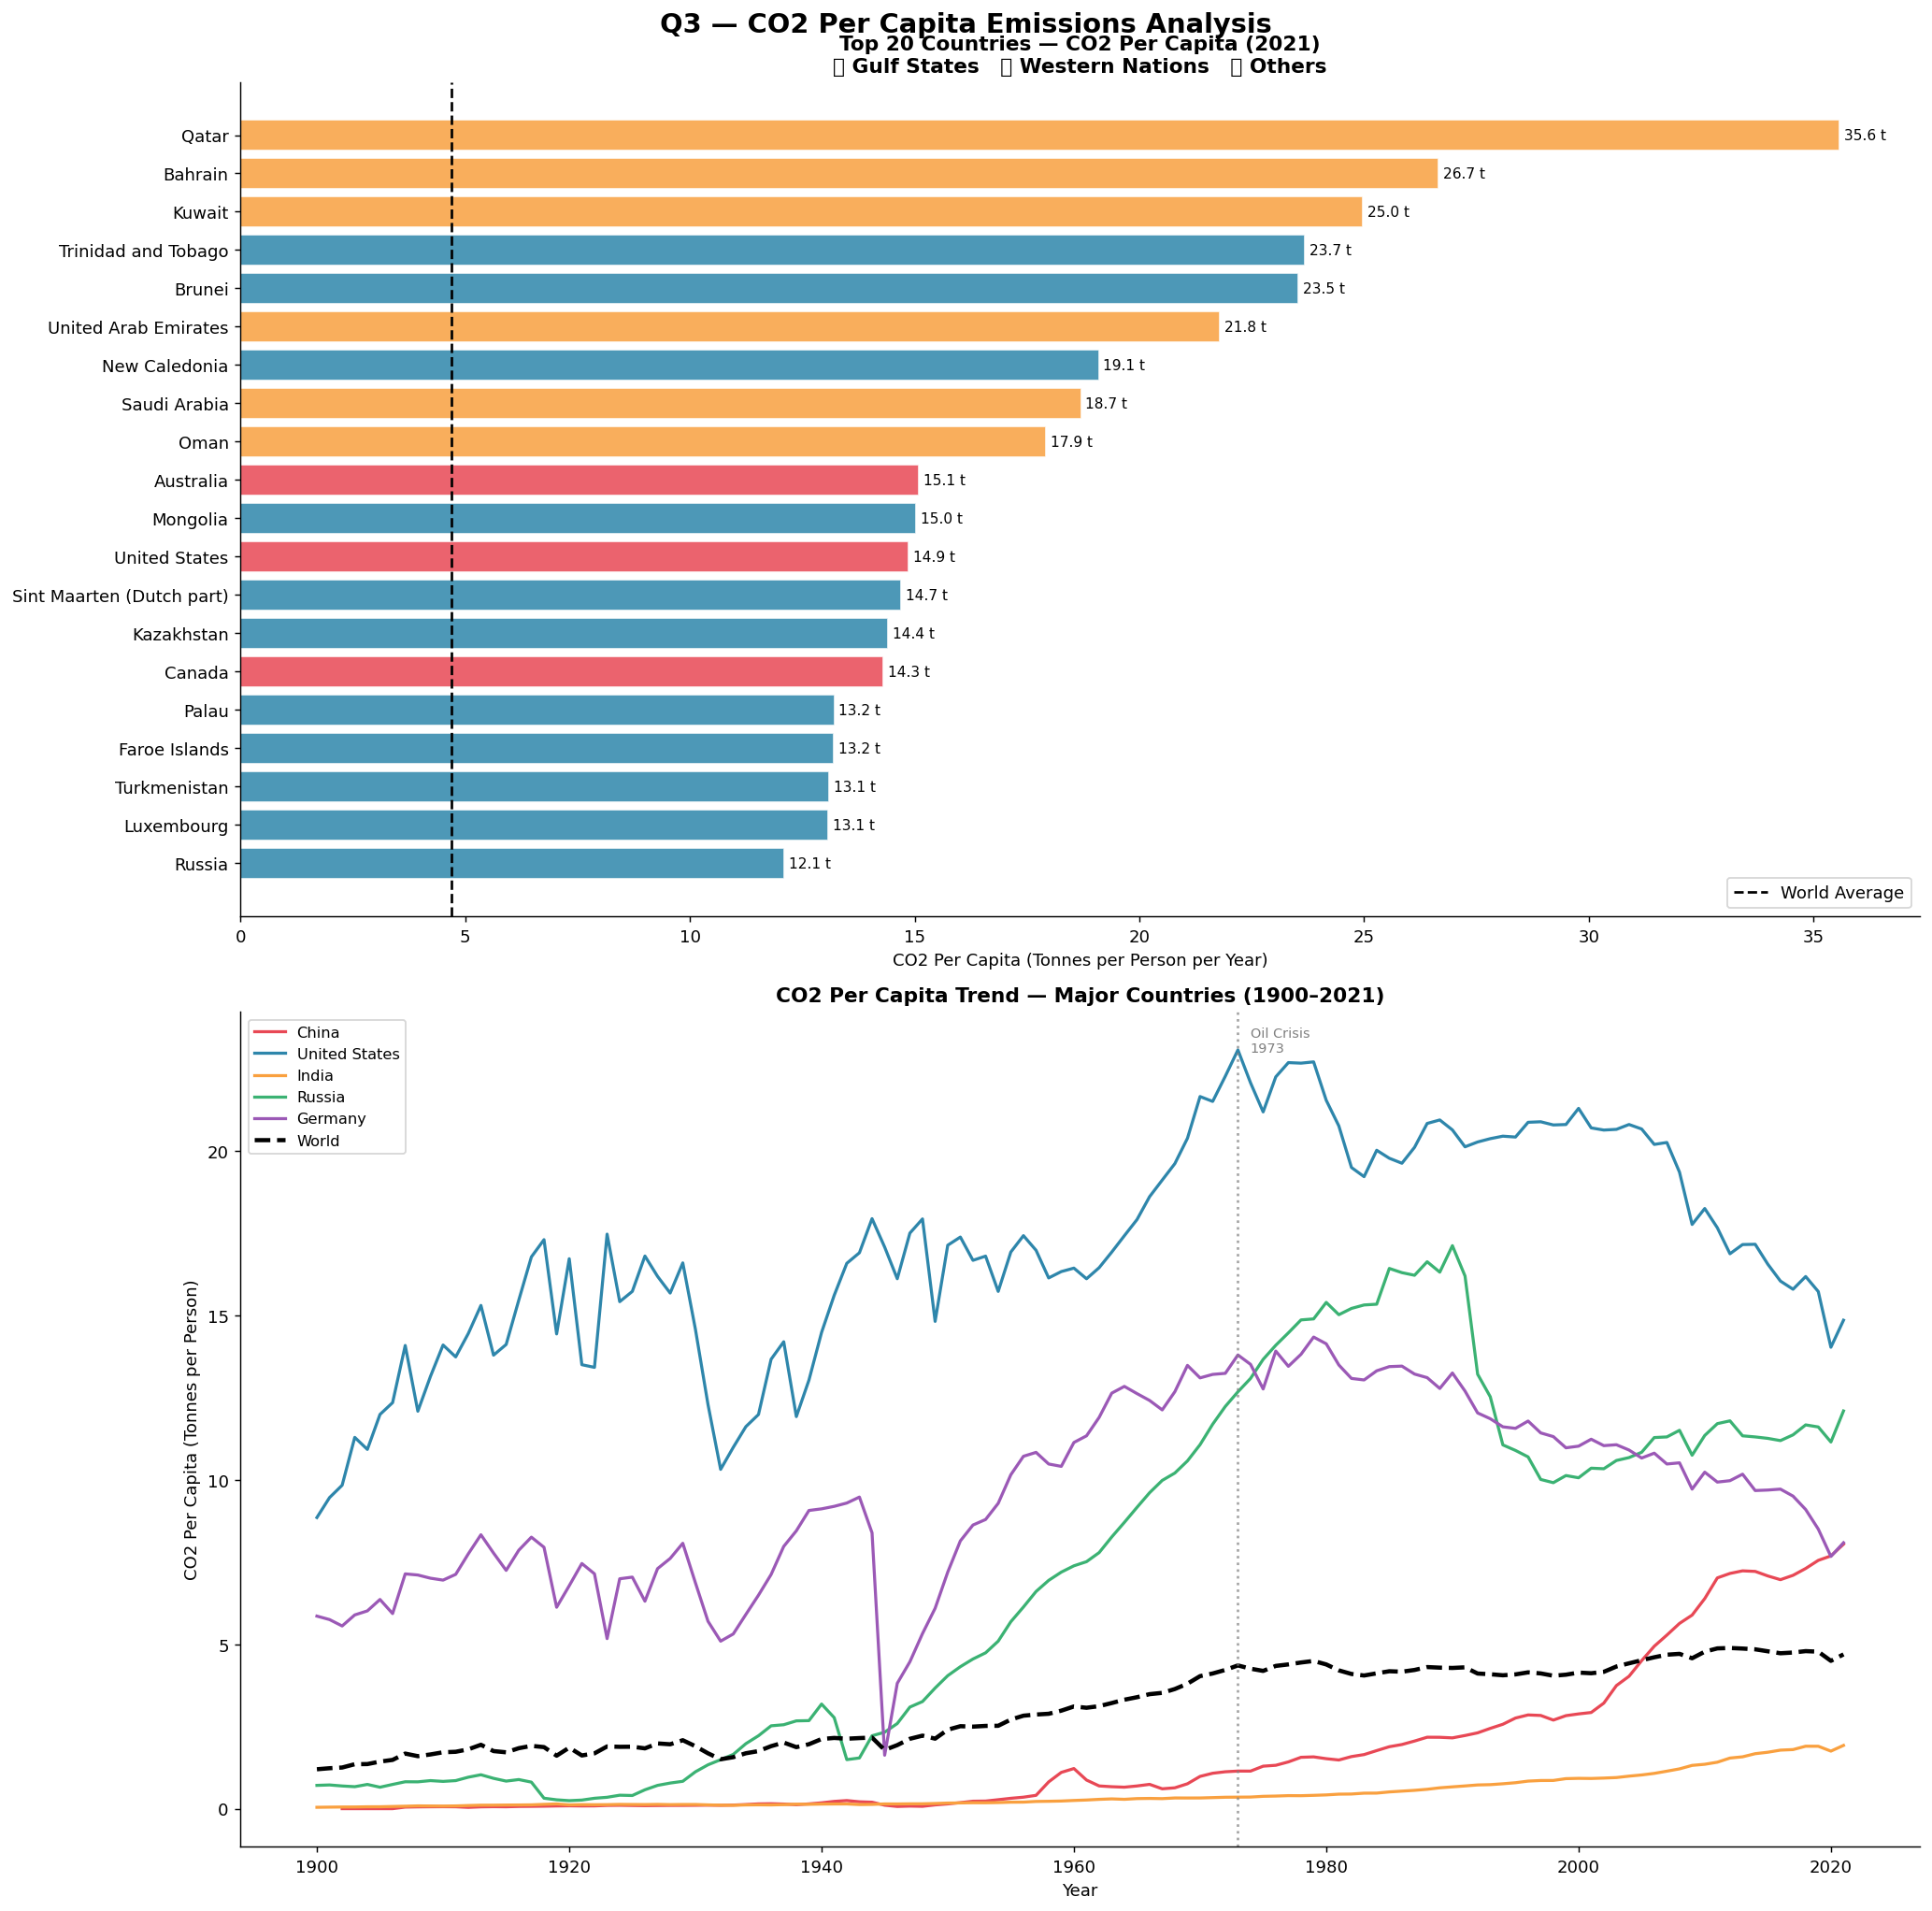

📊 Q3 — KEY NUMBERS

  🥇 Highest per capita : Qatar — 35.6 tonnes/person
  🥈 2nd highest        : Bahrain — 26.7 tonnes/person
  🥉 3rd highest        : Kuwait — 25.0 tonnes/person

  🌍 World average      : 4.7 tonnes/person
  → China                : 8.0 tonnes/person
  → United States        : 14.9 tonnes/person
  → India                : 1.9 tonnes/person

✅ Q3 charts saved to Visualizations folder!


In [9]:
# ============================================================
# Cell 15 — Q3: Where Does the Average Person Emit the Most?
# ============================================================

# ── Top 20 Countries by CO2 Per Capita in 2021 ───────────────
top20_pc = (df_clean[df_clean['year'] == 2021]
            .dropna(subset=['co2_per_capita'])
            .nlargest(20, 'co2_per_capita')
            [['country', 'co2_per_capita', 'population', 'co2']]
            .reset_index(drop=True))

# ── Per Capita Trend — Major Countries ───────────────────────
trend_countries = ['China', 'United States', 'India',
                   'Russia', 'Germany', 'World']
trend_data = {}
for c in trend_countries:
    if c == 'World':
        d = df_world[df_world['year'] >= 1900][
            ['year','co2_per_capita']].dropna()
    else:
        d = df_clean[(df_clean['country'] == c) &
                     (df_clean['year'] >= 1900)][
            ['year','co2_per_capita']].dropna()
    trend_data[c] = d

# ── Figure Setup ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 16))
fig.suptitle('Q3 — CO2 Per Capita Emissions Analysis',
             fontsize=16, fontweight='bold')

# ── Plot 1: Top 20 Bar Chart ─────────────────────────────────
ax1 = axes[0]
bar_colors = []
for country in top20_pc['country']:
    if country in ['Qatar', 'Kuwait', 'UAE',
                   'Bahrain', 'United Arab Emirates',
                   'Saudi Arabia', 'Oman']:
        bar_colors.append(COLORS['accent'])
    elif country in ['United States', 'Canada', 'Australia']:
        bar_colors.append(COLORS['secondary'])
    else:
        bar_colors.append(COLORS['primary'])

bars = ax1.barh(top20_pc['country'][::-1],
                top20_pc['co2_per_capita'][::-1],
                color=bar_colors[::-1],
                alpha=0.85, edgecolor='white')

for bar, val in zip(bars, top20_pc['co2_per_capita'][::-1]):
    ax1.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.1f} t', va='center', fontsize=8.5)

ax1.set_title('Top 20 Countries — CO2 Per Capita (2021)\n'
              '🟠 Gulf States   🔴 Western Nations   🔵 Others',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('CO2 Per Capita (Tonnes per Person per Year)')
ax1.axvline(world['co2_per_capita'].iloc[-1] if 'co2_per_capita'
            in world.columns else 4.7,
            color='black', linestyle='--',
            linewidth=1.5, label='World Average')
ax1.legend()

# ── Plot 2: Per Capita Trend Lines ───────────────────────────
ax2 = axes[1]
line_colors = [COLORS['secondary'], COLORS['primary'],
               COLORS['accent'], COLORS['green'],
               '#9B59B6', 'black']
line_styles = ['-', '-', '-', '-', '-', '--']

for (country, data), color, ls in zip(trend_data.items(),
                                       line_colors, line_styles):
    lw = 2.5 if country == 'World' else 1.8
    ax2.plot(data['year'], data['co2_per_capita'],
             label=country, color=color,
             linewidth=lw, linestyle=ls)

ax2.set_title('CO2 Per Capita Trend — Major Countries (1900–2021)',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('CO2 Per Capita (Tonnes per Person)')
ax2.legend(loc='upper left', fontsize=9)
ax2.axvline(1973, color='gray', linestyle=':',
            linewidth=1.5, alpha=0.7)
ax2.text(1974, ax2.get_ylim()[1] * 0.95,
         'Oil Crisis\n1973', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/03_CO2_Per_Capita.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Key Numbers ───────────────────────────────────────────────
print("=" * 50)
print("📊 Q3 — KEY NUMBERS")
print("=" * 50)
print(f"\n  🥇 Highest per capita : "
      f"{top20_pc.iloc[0]['country']} — "
      f"{top20_pc.iloc[0]['co2_per_capita']:.1f} tonnes/person")
print(f"  🥈 2nd highest        : "
      f"{top20_pc.iloc[1]['country']} — "
      f"{top20_pc.iloc[1]['co2_per_capita']:.1f} tonnes/person")
print(f"  🥉 3rd highest        : "
      f"{top20_pc.iloc[2]['country']} — "
      f"{top20_pc.iloc[2]['co2_per_capita']:.1f} tonnes/person")

# World average
world_pc = df_world.loc[df_world['year']==2021,
                         'co2_per_capita'].values
if len(world_pc) > 0:
    print(f"\n  🌍 World average      : {world_pc[0]:.1f} tonnes/person")

# China vs USA per capita
for country in ['China', 'United States', 'India']:
    val = df_clean.loc[(df_clean['country'] == country) &
                       (df_clean['year'] == 2021),
                       'co2_per_capita'].values
    if len(val) > 0:
        print(f"  → {country:<20} : {val[0]:.1f} tonnes/person")

print(f"\n✅ Q3 charts saved to Visualizations folder!")

## 🌱 Question 4 — How Have Fossil Fuel & Land Use Emissions Changed Over Time?

### Context

Not all CO2 is created equal. Emissions come from two fundamentally 
different sources:

- 🏭 **Fossil Fuels** — burning coal, oil, and gas for energy & industry
- 🌳 **Land Use Change** — deforestation, agriculture, and soil disturbance

Understanding how each source has evolved helps us identify **where 
intervention is most needed** and which sectors drive the crisis.

### What We Will Analyze

- **Stacked area chart** — coal, oil, gas, and cement over time
- **Fossil fuels vs. land use** — how their relative contributions 
  have shifted since 1850
- **The energy transition** — is coal declining in favor of gas?

### 📐 Metrics Used

| Column | Description |
|---|---|
| `coal_co2` | Emissions from coal combustion |
| `oil_co2` | Emissions from oil combustion |
| `gas_co2` | Emissions from gas combustion |
| `cement_co2` | Emissions from cement production |
| `land_use_change_co2` | Emissions from deforestation & land change |

> All values in **million tonnes (Mt)** — World-level data from `df_world`

### 💡 Hypothesis
> **Coal** dominated early industrialization but is now being replaced  
> by **oil and gas**. Meanwhile **land use** emissions, though smaller,  
> have remained stubbornly persistent throughout history.

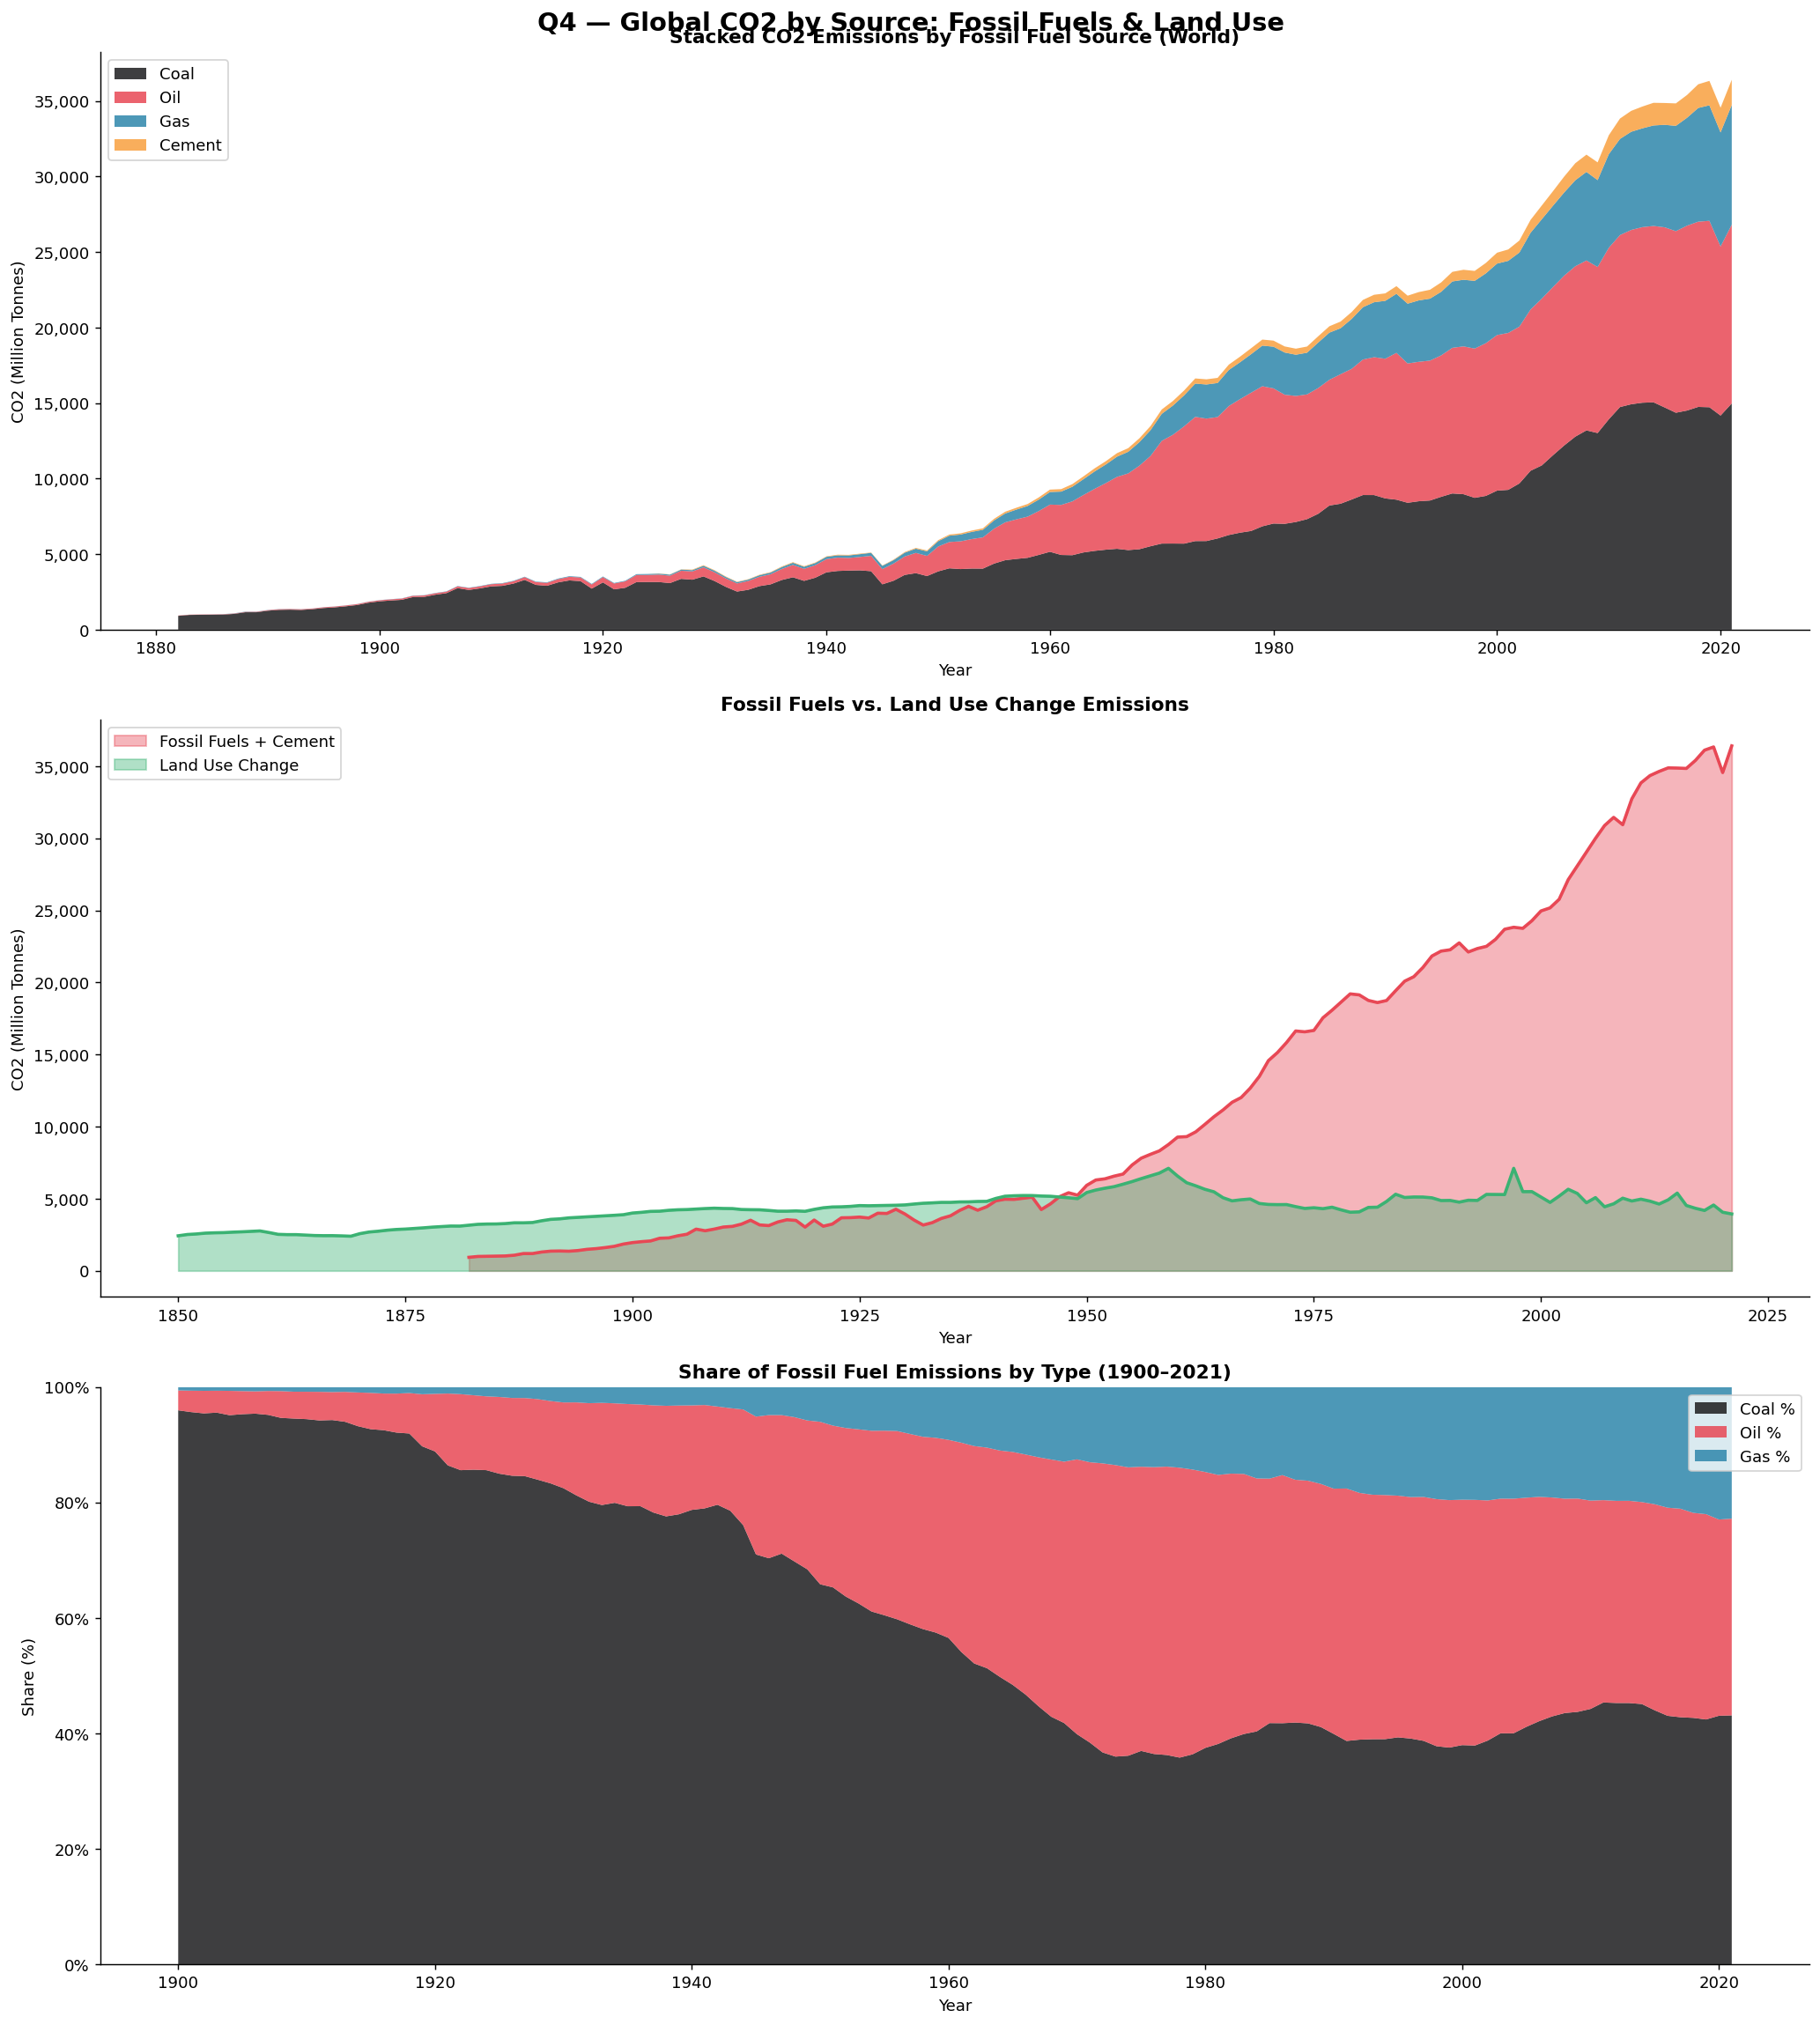

📊 Q4 — KEY NUMBERS (2021)

  🪨 Coal   :   14,980 Mt  (41.1%)
  🛢️  Oil    :   11,837 Mt  (32.5%)
  💨 Gas    :    7,922 Mt  (21.8%)
  🏗️  Cement :    1,673 Mt  (4.6%)

  Total Fossil : 36,411 Mt
  🌳 Land Use  : 3,939 Mt

✅ Q4 charts saved to Visualizations folder!


In [10]:
# ============================================================
# Cell 17 — Q4: Fossil Fuels & Land Use Over Time
# ============================================================

# ── Prepare World-Level Source Data ─────────────────────────
source_cols = ['year', 'coal_co2', 'oil_co2', 
               'gas_co2', 'cement_co2', 'land_use_change_co2']

world_sources = df_world[source_cols].dropna(
    subset=['coal_co2', 'oil_co2', 'gas_co2']).copy()

# ── Figure Setup ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Q4 — Global CO2 by Source: Fossil Fuels & Land Use',
             fontsize=16, fontweight='bold')

# ── Plot 1: Stacked Area — All Sources ───────────────────────
ax1 = axes[0]
ax1.stackplot(
    world_sources['year'],
    world_sources['coal_co2'].fillna(0),
    world_sources['oil_co2'].fillna(0),
    world_sources['gas_co2'].fillna(0),
    world_sources['cement_co2'].fillna(0),
    labels=['Coal', 'Oil', 'Gas', 'Cement'],
    colors=[COLORS['dark'], COLORS['secondary'],
            COLORS['primary'], COLORS['accent']],
    alpha=0.85
)
ax1.set_title('Stacked CO2 Emissions by Fossil Fuel Source (World)',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 (Million Tonnes)')
ax1.legend(loc='upper left', fontsize=10)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Plot 2: Fossil Fuels vs Land Use ─────────────────────────
ax2 = axes[1]

# Total fossil fuels per year
world_sources['fossil_total'] = (
    world_sources['coal_co2'].fillna(0) +
    world_sources['oil_co2'].fillna(0)  +
    world_sources['gas_co2'].fillna(0)  +
    world_sources['cement_co2'].fillna(0)
)

# Land use — use separate df (different year coverage)
luc = df_world[['year', 'land_use_change_co2']].dropna()

ax2.fill_between(world_sources['year'],
                 world_sources['fossil_total'],
                 alpha=0.4, color=COLORS['secondary'],
                 label='Fossil Fuels + Cement')
ax2.plot(world_sources['year'],
         world_sources['fossil_total'],
         color=COLORS['secondary'], linewidth=2)

ax2.fill_between(luc['year'],
                 luc['land_use_change_co2'].clip(lower=0),
                 alpha=0.4, color=COLORS['green'],
                 label='Land Use Change')
ax2.plot(luc['year'],
         luc['land_use_change_co2'].clip(lower=0),
         color=COLORS['green'], linewidth=2)

ax2.set_title('Fossil Fuels vs. Land Use Change Emissions',
              fontweight='bold', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('CO2 (Million Tonnes)')
ax2.legend(loc='upper left', fontsize=10)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Plot 3: Coal vs Oil vs Gas Share Over Time ───────────────
ax3 = axes[2]
modern_src = world_sources[world_sources['year'] >= 1900].copy()
total      = (modern_src['coal_co2'].fillna(0) +
              modern_src['oil_co2'].fillna(0)  +
              modern_src['gas_co2'].fillna(0))

coal_share = modern_src['coal_co2'].fillna(0) / total * 100
oil_share  = modern_src['oil_co2'].fillna(0)  / total * 100
gas_share  = modern_src['gas_co2'].fillna(0)  / total * 100

ax3.stackplot(
    modern_src['year'],
    coal_share, oil_share, gas_share,
    labels=['Coal %', 'Oil %', 'Gas %'],
    colors=[COLORS['dark'], COLORS['secondary'], COLORS['primary']],
    alpha=0.85
)
ax3.set_title('Share of Fossil Fuel Emissions by Type (1900–2021)',
              fontweight='bold', fontsize=12)
ax3.set_xlabel('Year')
ax3.set_ylabel('Share (%)')
ax3.set_ylim(0, 100)
ax3.legend(loc='upper right', fontsize=10)
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig(f'{VIZ_PATH}/04_Fossil_vs_LandUse.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Key Numbers ───────────────────────────────────────────────
print("=" * 50)
print("📊 Q4 — KEY NUMBERS (2021)")
print("=" * 50)
latest_src = world_sources[world_sources['year'] == 2021]
if not latest_src.empty:
    row = latest_src.iloc[0]
    total_2021 = (row['coal_co2'] + row['oil_co2'] +
                  row['gas_co2'] + row['cement_co2'])
    print(f"\n  🪨 Coal   : {row['coal_co2']:>8,.0f} Mt  "
          f"({row['coal_co2']/total_2021*100:.1f}%)")
    print(f"  🛢️  Oil    : {row['oil_co2']:>8,.0f} Mt  "
          f"({row['oil_co2']/total_2021*100:.1f}%)")
    print(f"  💨 Gas    : {row['gas_co2']:>8,.0f} Mt  "
          f"({row['gas_co2']/total_2021*100:.1f}%)")
    print(f"  🏗️  Cement : {row['cement_co2']:>8,.0f} Mt  "
          f"({row['cement_co2']/total_2021*100:.1f}%)")
    print(f"\n  Total Fossil : {total_2021:,.0f} Mt")

luc_2021 = luc.loc[luc['year'] == 2021,
                    'land_use_change_co2'].values
if len(luc_2021) > 0:
    print(f"  🌳 Land Use  : {luc_2021[0]:,.0f} Mt")

print(f"\n✅ Q4 charts saved to Visualizations folder!")

## 💡 Phase 5 — Key Insights & Recommendations

### 🔍 What the Data Tells Us

---

#### Q1 — Global CO2 Trend
> 📈 Global emissions grew by **+1,802%** from 1900 to 2021

- CO2 was negligible until the **Industrial Revolution (~1760)**
- The **Post-WW2 economic boom (1945–1973)** triggered the steepest 
  acceleration in history
- The **1973 Oil Crisis** caused a rare but temporary slowdown
- **COVID-19 (2020)** produced a visible dip — quickly reversed in 2021
- ⚠️ There is **no sustained decline** visible in the full timeline

---

#### Q2 — Top Emitters
> 🏭 Just 10 countries produce **68.3%** of global CO2

- In 1900: **UK and Europe** dominated — early industrializers
- By 1970: **USA** was unchallenged at 4,340 Mt
- By 2021: **China overtook everyone** at 11,472 Mt (30.9% alone)
- **China + USA + India = 51.7%** of all global emissions
- The center of gravity has shifted decisively from **West to East**

---

#### Q3 — Per Capita Emissions
> 👤 The world average is **4.7 tonnes/person** — hiding extreme inequality

- **Qatar (35.6 t)** emits 19x more per person than **India (1.9 t)**
- **Gulf oil states** dominate per-capita rankings — energy-intensive 
  economies with small populations
- **USA declining** since 1973 — efficiency gains and deindustrialization
- **China rising sharply** — still below USA but gap is closing fast
- High total emitters ≠ High per-capita emitters (China vs Qatar)

---

#### Q4 — Fossil Fuels vs Land Use
> 🌱 Fossil fuels now produce **9x more** CO2 than land use change

- **Coal** remains the single largest source at **41.1%** in 2021
- **Oil** surged post-1950 driven by transportation demand
- **Gas** is the fastest-growing source — marketed as "transition fuel"
- **Land use** emissions are flat but persistent at ~3,939 Mt/year
- Coal's share fell from 95% → 41% but its **absolute volume keeps rising**

---

### 🎯 Data-Driven Recommendations

| Priority | Recommendation | Target |
|---|---|---|
| 🔴 **Critical** | Accelerate coal phase-out globally | China, India, USA |
| 🔴 **Critical** | Hold China & USA accountable for 44% of emissions | Policy & diplomacy |
| 🟠 **High** | Address Gulf states' extreme per-capita footprints | Qatar, Bahrain, Kuwait |
| 🟠 **High** | Stop treating gas as a "green transition" — it is still fossil fuel | All nations |
| 🟡 **Medium** | Halt deforestation — land use adds ~3,939 Mt annually | Tropical nations |
| 🟡 **Medium** | Support India's clean development — before it follows China's path | India |
| 🟢 **Ongoing** | Learn from USA & Germany's per-capita decline — replicate globally | Developing nations |

---

### 📌 Final Thought

> *"The data is unambiguous — emissions have never truly declined at the  
> global level. Every dip (wars, crises, pandemics) was followed by a  
> rebound. Only **structural change** in energy systems will bend the curve."*

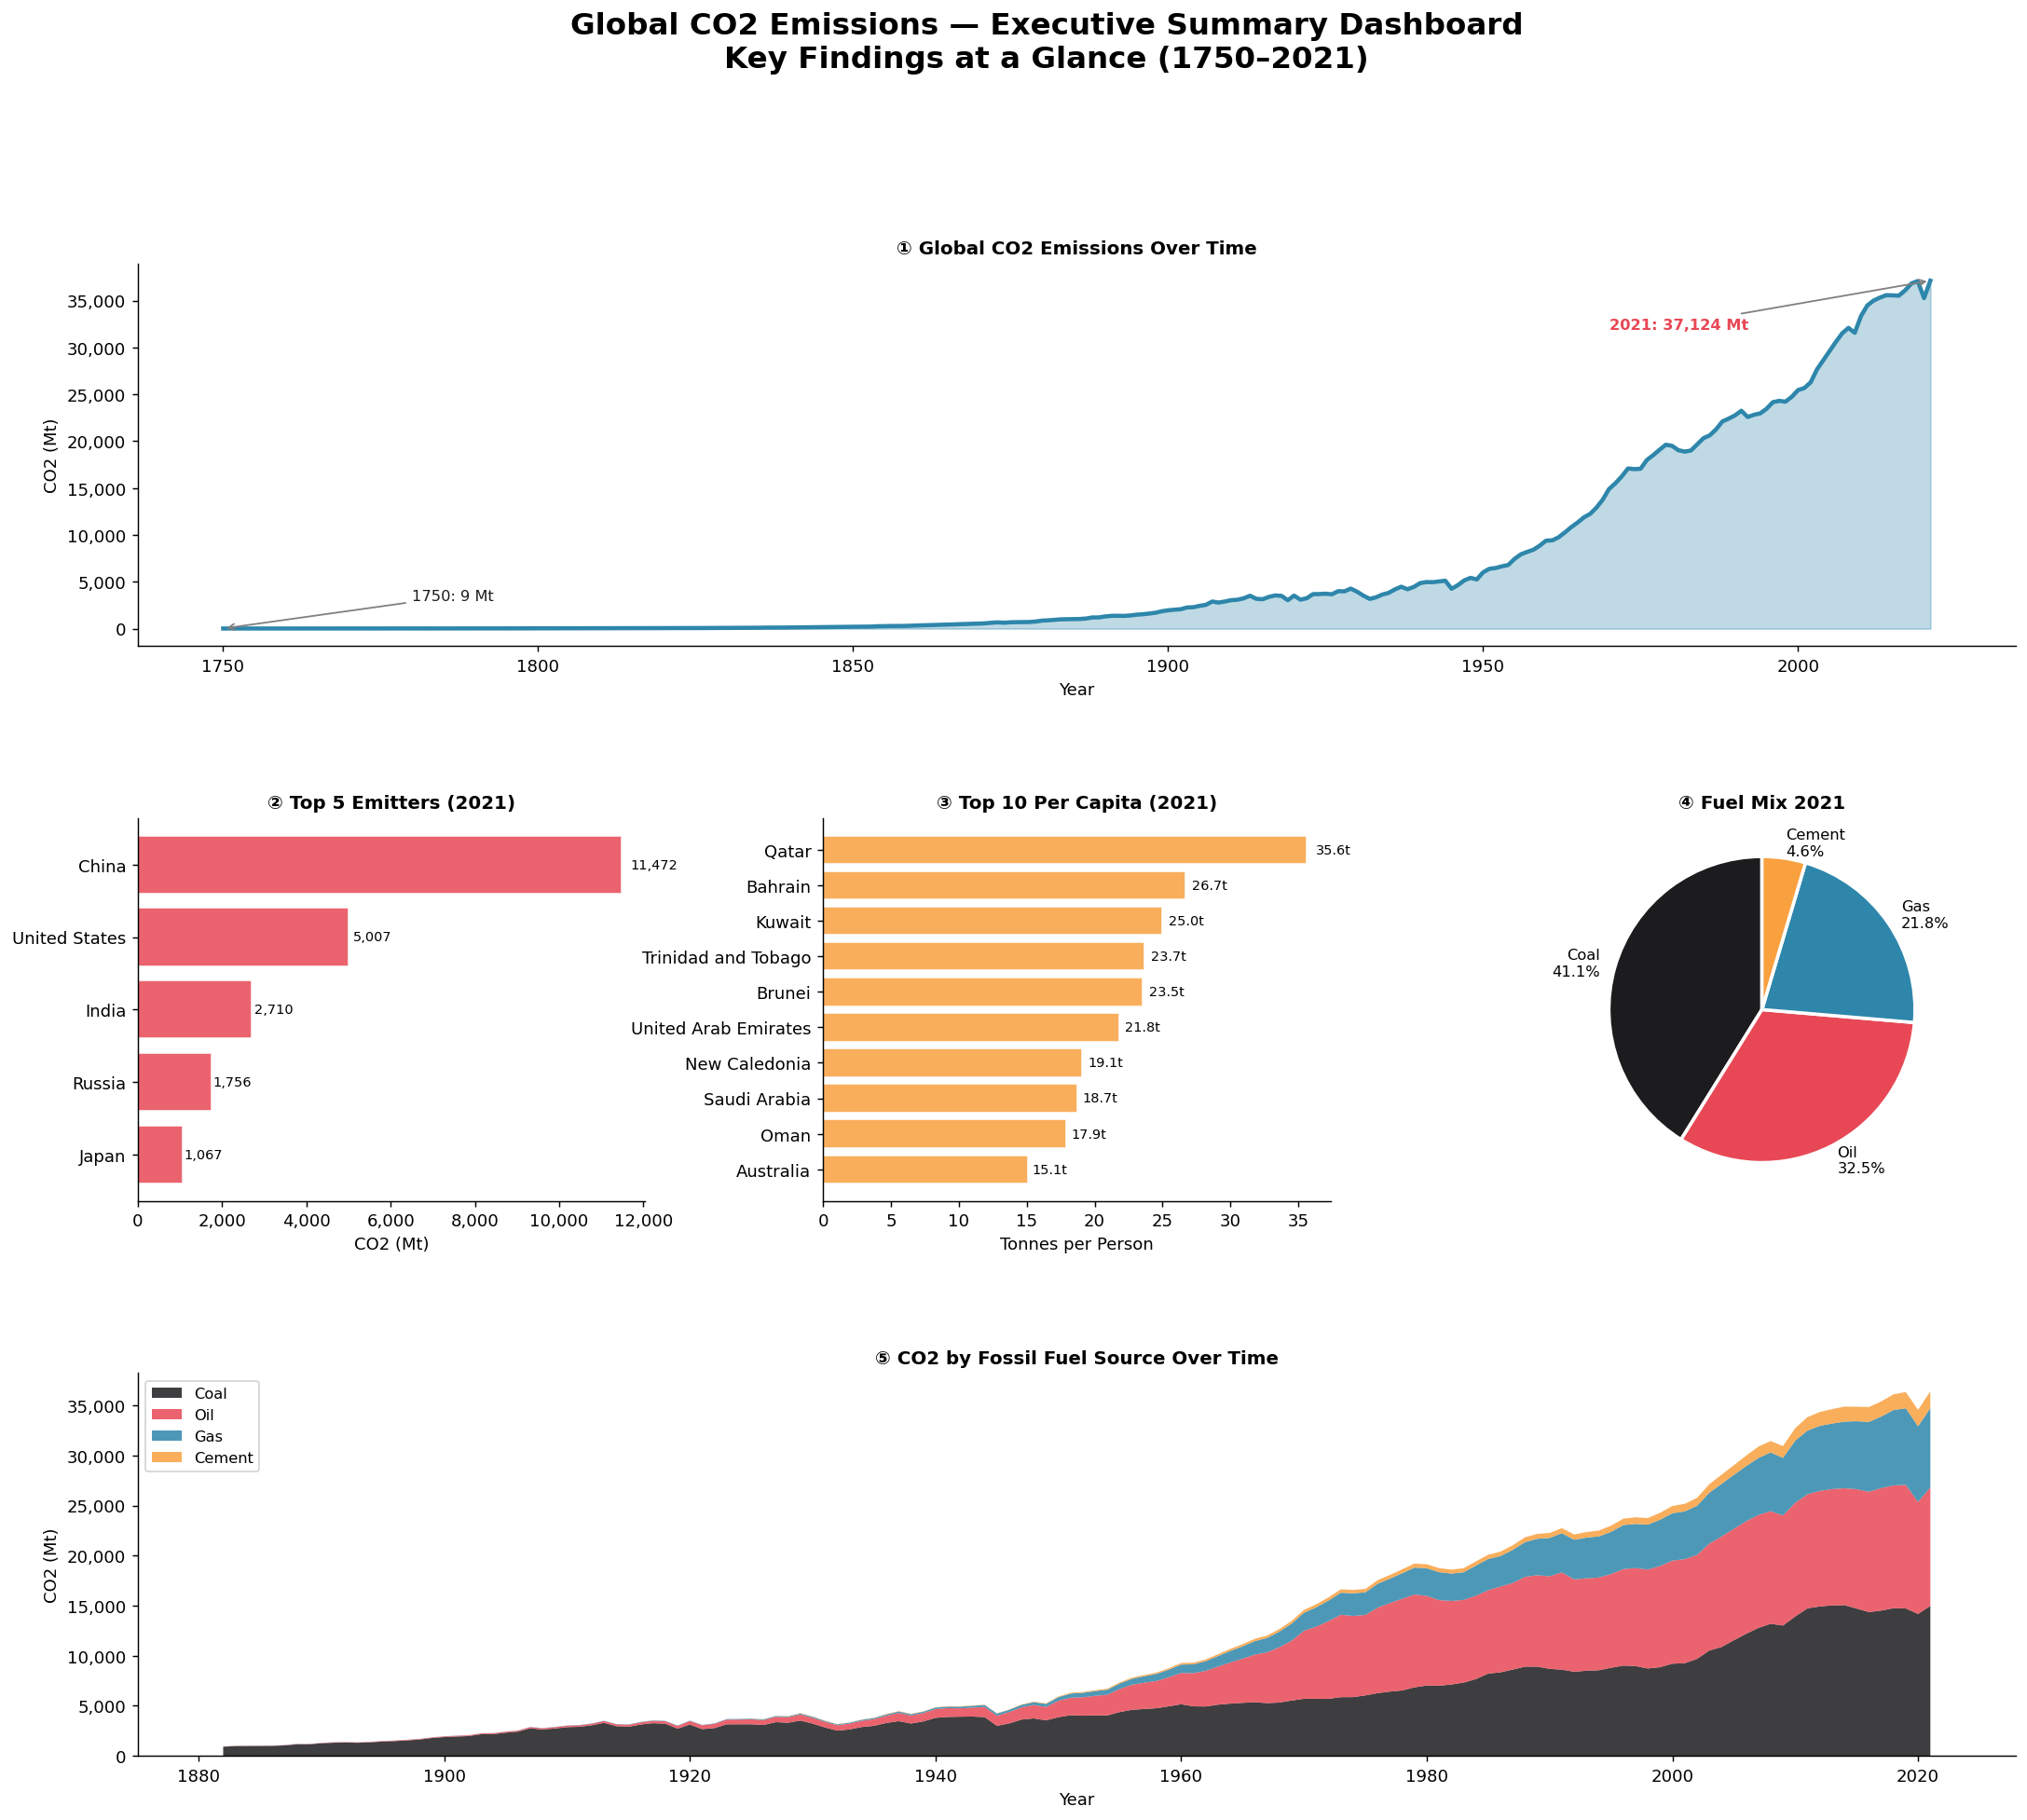

✅ Executive Summary Dashboard saved!


In [11]:
# ============================================================
# Cell 19 — Final Summary Dashboard
# ============================================================

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Global CO2 Emissions — Executive Summary Dashboard\n'
             'Key Findings at a Glance (1750–2021)',
             fontsize=18, fontweight='bold', y=1.01)

# ── Grid Layout ───────────────────────────────────────────────
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])   # Full width — global trend
ax2 = fig.add_subplot(gs[1, 0])   # Top emitters 2021
ax3 = fig.add_subplot(gs[1, 1])   # Per capita top 10
ax4 = fig.add_subplot(gs[1, 2])   # Fuel mix pie 2021
ax5 = fig.add_subplot(gs[2, :])   # Stacked sources timeline

# ── Plot 1: Global Trend ─────────────────────────────────────
world_co2 = df_world.dropna(subset=['co2'])
ax1.fill_between(world_co2['year'], world_co2['co2'],
                 alpha=0.3, color=COLORS['primary'])
ax1.plot(world_co2['year'], world_co2['co2'],
         color=COLORS['primary'], linewidth=2.5)
ax1.set_title('① Global CO2 Emissions Over Time',
              fontweight='bold', fontsize=11)
ax1.set_xlabel('Year')
ax1.set_ylabel('CO2 (Mt)')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Annotate start & end
ax1.annotate(f"1750: 9 Mt",
             xy=(1750, 9), xytext=(1780, 3000),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9, color=COLORS['dark'])
ax1.annotate(f"2021: 37,124 Mt",
             xy=(2021, 37124), xytext=(1970, 32000),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9, color=COLORS['secondary'],
             fontweight='bold')

# ── Plot 2: Top 5 Emitters 2021 ──────────────────────────────
top5 = get_top_emitters(2021, n=5)
bars = ax2.barh(top5['country'][::-1],
                top5['co2'][::-1],
                color=COLORS['secondary'],
                alpha=0.85, edgecolor='white')
for bar, val in zip(bars, top5['co2'][::-1]):
    ax2.text(bar.get_width() * 1.02,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f}', va='center', fontsize=8)
ax2.set_title('② Top 5 Emitters (2021)',
              fontweight='bold', fontsize=11)
ax2.set_xlabel('CO2 (Mt)')
ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Plot 3: Top 10 Per Capita 2021 ───────────────────────────
top10_pc = (df_clean[df_clean['year'] == 2021]
            .dropna(subset=['co2_per_capita'])
            .nlargest(10, 'co2_per_capita')
            [['country', 'co2_per_capita']]
            .reset_index(drop=True))
bars3 = ax3.barh(top10_pc['country'][::-1],
                 top10_pc['co2_per_capita'][::-1],
                 color=COLORS['accent'],
                 alpha=0.85, edgecolor='white')
for bar, val in zip(bars3, top10_pc['co2_per_capita'][::-1]):
    ax3.text(bar.get_width() * 1.02,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}t', va='center', fontsize=8)
ax3.set_title('③ Top 10 Per Capita (2021)',
              fontweight='bold', fontsize=11)
ax3.set_xlabel('Tonnes per Person')

# ── Plot 4: Fuel Mix Pie 2021 ─────────────────────────────────
latest = world_sources[world_sources['year'] == 2021].iloc[0]
fuel_vals   = [latest['coal_co2'], latest['oil_co2'],
               latest['gas_co2'], latest['cement_co2']]
fuel_labels = [f'Coal\n41.1%', f'Oil\n32.5%',
               f'Gas\n21.8%', f'Cement\n4.6%']
fuel_colors = [COLORS['dark'], COLORS['secondary'],
               COLORS['primary'], COLORS['accent']]
ax4.pie(fuel_vals, labels=fuel_labels,
        colors=fuel_colors, startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2),
        textprops={'fontsize': 9})
ax4.set_title('④ Fuel Mix 2021',
              fontweight='bold', fontsize=11)

# ── Plot 5: Stacked Sources Timeline ─────────────────────────
ax5.stackplot(
    world_sources['year'],
    world_sources['coal_co2'].fillna(0),
    world_sources['oil_co2'].fillna(0),
    world_sources['gas_co2'].fillna(0),
    world_sources['cement_co2'].fillna(0),
    labels=['Coal', 'Oil', 'Gas', 'Cement'],
    colors=[COLORS['dark'], COLORS['secondary'],
            COLORS['primary'], COLORS['accent']],
    alpha=0.85
)
ax5.set_title('⑤ CO2 by Fossil Fuel Source Over Time',
              fontweight='bold', fontsize=11)
ax5.set_xlabel('Year')
ax5.set_ylabel('CO2 (Mt)')
ax5.legend(loc='upper left', fontsize=9)
ax5.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.savefig(f'{VIZ_PATH}/05_Executive_Summary_Dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Executive Summary Dashboard saved!")

## 📝 Phase 6 — Final Conclusion & Non-Technical Summary

---

### 🌍 The Story of Carbon: A 270-Year Journey

Imagine the Earth's atmosphere as a bank account.

For thousands of years, that account was perfectly balanced —
nature absorbed exactly as much CO2 as it released.

Then, around 1760, humanity made its first large "withdrawal" —
burning coal to power the Industrial Revolution in Britain.
The balance began to tip.

By 1900, the world was emitting **1,952 million tonnes** of CO2 per year.
A large number — but nothing compared to what came next.

The post-World War II economic boom unleashed an unprecedented
appetite for energy. Factories multiplied. Cars filled the roads.
Cities expanded overnight. By 2021, annual emissions had reached
**37,124 million tonnes** — a **1,802% increase** in just 120 years.

---

### 🏭 Who Is Responsible?

The burden is not shared equally.

Just **10 countries** are responsible for **68.3%** of all CO2 emitted today.

At the top stands **China** — now emitting 11,472 million tonnes per year,
nearly **one third of the entire planet's emissions**.
Behind it, the **United States** at 5,007 Mt, and **India** rising fast at 2,710 Mt.

But here is where the story gets more nuanced.

China has **1.4 billion people**. Its emissions per person?
Just **8 tonnes** annually.

Compare that to **Qatar** — a nation of 3 million —
where every single person emits **35.6 tonnes per year**.
That is **7.5 times the world average**.

The Gulf states, powered by oil wealth and energy-intensive lifestyles,
top the per-capita rankings by a wide margin.

---

### ⚡ What Are We Actually Burning?

In 2021, the breakdown was stark:

- 🪨 **Coal** — 14,980 Mt — *still* the largest single source at 41%
- 🛢️ **Oil** — 11,837 Mt — powering our cars and planes at 32%
- 💨 **Gas** — 7,922 Mt — the so-called "clean" fossil fuel at 22%
- 🏗️ **Cement** — 1,673 Mt — building our cities at 5%
- 🌳 **Deforestation** — 3,939 Mt — a silent, persistent contributor

Coal's share has fallen from 95% in 1900 to 41% today —
but its **absolute volume has never stopped growing**.
We have not replaced coal. We have simply added oil and gas on top of it.

---

### 🎯 What Must Change?

The data points to three urgent priorities:

**1. Target the giants.**
China, the USA, and India together produce over half of global emissions.
No climate strategy succeeds without their full commitment.

**2. End coal — truly.**
Coal remains the dirtiest and largest source.
Every coal plant still operating is a direct threat to climate targets.

**3. Rethink "natural gas."**
Gas is cleaner than coal — but it is still a fossil fuel.
At 7,922 Mt per year, it cannot be called a climate solution.

---

### 💬 Closing Thought

> *"The atmosphere does not negotiate.*
> *It does not care about economic growth, political cycles, or quarterly profits.*
> *It only responds to the total amount of carbon we release.*
> *The data is clear. The question now is whether our decisions will match it."*

---
*Analysis by Dr. Bahaa | Python & Jupyter Notebook | June 2026*
*Data Source: Our World in Data — Global CO2 and GHG Emissions Dataset*